**1. Loading of scenes and labelling of locations**

Imports

In [1]:
import os
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"
import torch
import torch.nn as nn
from pathlib import Path
import numpy as np
from scipy.spatial import KDTree
from sklearn.neighbors import BallTree

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

Using device: cuda


Define Hyperparameters

In [2]:
spatial_filtering_dist_threshold = 0.1
spatial_filtering_rot_threshold = 3.0

#only used in the old version without subroutes
location_clustering_dist_threshold = 1.5
location_clustering_rot_weight = 1.0

# only used in the new version with subroutes
subroutes_dist_threshold = 10.0
subroutes_rot_threshold = 45.0
location_clustering_dist_threshold_new = 3.0
location_clustering_rot_threshold_new = 15.0

day_night_pairing_dist_threshold = 3.0
day_night_pairing_rot_threshold = 5.0
alpha = 10.0
num_epochs = 1

Define paths and select a test scene (the rest is used for training)

In [3]:
dataset_dir = Path('/home/paul-hoheisel/Documents/SITD-setup-and-data/day-and-night-data/aria')
outputs = Path('outputs/oxford_hloc')

all_scenes = ['bodleian-library', 'hb-allen-centre', 'keble-college', 'observatory-quarter', 'oxford-robotics-institute']
all_scenes_image_subfoldernames = ['day_night_44', 'day_night_10', 'day_night_24', 'day_night_25', 'day_night_21']
all_scenes_day_subfoldernames = ['day_23', 'day_6', 'day_13', 'day_13', 'day_13']
all_scenes_night_subfoldernames = ['night_21', 'night_4', 'night_11', 'night_12', 'night_08']
test_scene = 0
test_scene_dir = dataset_dir / all_scenes[test_scene]
test_img_subfolder = all_scenes_image_subfoldernames[test_scene]
test_images_root = test_scene_dir / f'ns_processed/multi/undistorted_all_valid/{test_img_subfolder}/camera-rgb'

# select scene for training

train_scenes = [1, 2, 3, 4]  # Alle Szenen außer der Test-Szene (0)
scene_dirs = np.zeros(len(train_scenes), dtype=object)
scene_subfolders = np.array([None] * len(train_scenes), dtype=object)
scene_images_roots = np.array([None] * len(train_scenes), dtype=object)
day_images_roots = np.array([None] * len(train_scenes), dtype=object)
night_images_roots = np.array([None] * len(train_scenes), dtype=object)
for i in range (len(train_scenes)):
    scene = train_scenes[i]
    scene_dirs[i] = dataset_dir / all_scenes[scene]
    scene_subfolders[i] = all_scenes_image_subfoldernames[scene]
    scene_images_roots[i] = scene_dirs[i] / f'ns_processed/multi/undistorted_all_valid/{scene_subfolders[i]}/camera-rgb'
    day_images_roots[i] = scene_dirs[i] / f'ns_processed/multi/undistorted_all_valid/{all_scenes_day_subfoldernames[scene]}/camera-rgb'
    night_images_roots[i] = scene_dirs[i] / f'ns_processed/multi/undistorted_all_valid/{all_scenes_night_subfoldernames[scene]}/camera-rgb'



Create dictionary of camera poses for the day images and for the night images

In [4]:
transforms_path_day = []
transforms_path_night = []
transforms_path_combined = []

for i in range (len(train_scenes)):
    scene = train_scenes[i]
    transforms_path_day.append(Path(f'/home/paul-hoheisel/Documents/SITD-setup-and-data/day-and-night-data/aria/{all_scenes[scene]}/ns_processed/multi/undistorted_all_valid/{all_scenes_day_subfoldernames[scene]}/transforms_opencv.json'))
    transforms_path_night.append(Path(f'/home/paul-hoheisel/Documents/SITD-setup-and-data/day-and-night-data/aria/{all_scenes[scene]}/ns_processed/multi/undistorted_all_valid/{all_scenes_night_subfoldernames[scene]}/transforms_opencv.json'))
    transforms_path_combined.append(Path(f'/home/paul-hoheisel/Documents/SITD-setup-and-data/day-and-night-data/aria/{all_scenes[scene]}/ns_processed/multi/undistorted_all_valid/{scene_subfolders[i]}/transforms_opencv.json'))

import json
import numpy as np

def get_pose_dicts(json_path, day_image_names, night_image_names):
    with open(json_path, 'r') as f:
        data = json.load(f)
    
    day_pose_dict = {}
    night_pose_dict = {}
    for frame in data['frames']:
        full_path = frame['file_path']
        raw_name = full_path.split('/')[-1]  # "vrs00_59673489879.jpg"
        if '_' in raw_name:
            clean_name = raw_name.split('_', 1)[1]  # "59673489879.jpg"
        else:
            clean_name = raw_name
        
        # Die 4x4 Matrix (Camera-to-World)
        matrix = np.array(frame['transform_matrix'])

        R_w2c = matrix[0:3, 0:3]
        t_w2c = matrix[0:3, 3]
        
        # --- MATHEMATISCHE TRANSFORMATION (C2W) ---
        # Invertierung für das weltfeste Koordinatensystem
        R_c2w = R_w2c.T
        c_world = -R_c2w @ t_w2c
        
        if(clean_name in day_image_names):
            day_pose_dict[clean_name] = {
            'c_world': c_world,          
            'R_c2w': R_c2w,              
            'R_w2c_orig': R_w2c,
            't_w2c_orig': t_w2c
            }
        
        elif(clean_name in night_image_names):
            night_pose_dict[clean_name] = {
            'c_world': c_world,          
            'R_c2w': R_c2w,              
            'R_w2c_orig': R_w2c,
            't_w2c_orig': t_w2c
            }
        
    return day_pose_dict, night_pose_dict





In [ ]:
print(transforms_path_combined)

[PosixPath('/home/paul-hoheisel/Documents/SITD-setup-and-data/day-and-night-data/aria/hb-allen-centre/ns_processed/multi/undistorted_all_valid/day_night_10/transforms_opencv.json'), PosixPath('/home/paul-hoheisel/Documents/SITD-setup-and-data/day-and-night-data/aria/keble-college/ns_processed/multi/undistorted_all_valid/day_night_24/transforms_opencv.json')]


In [5]:
def spatial_filtering(pose_dict, dist_threshold=0.2, angle_threshold=5.0):
    image_names = list(pose_dict.keys())
    current_translation, current_rotation = pose_dict[image_names[0]]['c_world'], pose_dict[image_names[0]]['R_c2w']
    for img_name in image_names[1:]:
        translation, rotation = pose_dict[img_name]['c_world'], pose_dict[img_name]['R_c2w']
        dist = np.linalg.norm(translation - current_translation)
        angle = np.arccos((np.trace(current_rotation.T @ rotation) - 1) / 2) * (180.0 / np.pi)
        if dist > dist_threshold or angle > angle_threshold:
            current_translation, current_rotation = translation, rotation
        else:
            del pose_dict[img_name]
    return pose_dict

In [6]:
def cluster_poses_with_matrices(dist_threshold=1.5, rot_weight=1.0, day_image_names=None, day_pose_dict=None):
    """
    translations: np.array (N, 3) -> [x, y, z]
    rotation_matrices: np.array (N, 3, 3) -> Die R-Matrizen
    rot_weight: Faktor, um den Einfluss der Rotation zu skalieren
    day_image_names: Liste der Bildnamen für die Tag-Poses
    """

    rotation_matrices = np.array([day_pose_dict[name]['R_c2w'] for name in day_image_names])
    translations = np.array([day_pose_dict[name]['c_world'] for name in day_image_names])

    # 1. Rotationsmatrizen flachklopfen (N, 9)
    R_flat = rotation_matrices.reshape(-1, 9)
    
    # 2. Features kombinieren: Translation (3) + Flattened R (9) = 12D Vektor
    # Wir skalieren R_flat, um das "Wackeln" der Aria-Brille im Clustering zu berücksichtigen
    combined_features = np.hstack([translations, R_flat * rot_weight])
    
    # 3. Clustering via BallTree (effizient für 12D)
    tree = BallTree(combined_features, leaf_size=40)
    
    visited = np.zeros(len(translations), dtype=bool)
    labels = {name: None for name in day_image_names}  # Bildname -> Cluster-ID
    cluster_id = 0
    
    # old "greedy" clustering that can overwrite clusters if a later pose is close to an already clustered one
    #for i in range(len(day_image_names)):
    #    if not visited[i]:
    #        # Suche alle Posen im gewichteten 12D-Radius
    #        indices = tree.query_radius(combined_features[i:i+1], r=dist_threshold)[0]
    ##        for idx in indices:
    #            labels[day_image_names[idx]] = cluster_id
    #        visited[indices] = True
    #        cluster_id += 1


    # non-overwriting clustering: only assign clusters to unlabeled images
    for i in range(len(day_image_names)):
        if not visited[i]:
            # Query radius around the unvisited anchor image
            indices = tree.query_radius(combined_features[i:i+1], r=dist_threshold)[0]
            
            # FILTER: Only take indices that have NOT been visited yet
            valid_indices = [idx for idx in indices if not visited[idx]]
            
            for idx in valid_indices:
                labels[day_image_names[idx]] = cluster_id
                
            visited[valid_indices] = True
            cluster_id += 1
            
    return labels



# tbd: assign night labels based on best_day_and_night_pair (below)

In [7]:
def find_best_day_night_pairs(poses_night, poses_day, dist_threshold=2, angle_threshold=10.0, day_labels=None, subroutes=None):
    """
    poses_night/day: Dict mit {'img_name': (rotation_matrix, translation_vec)}
    returns array containing (<name of night image>, <name of day image>, distance, angle difference)
    
    # 1. Daten für KD-Tree vorbereiten
    #if subroutes is not None:
    #    day_image_names = list()
        valid_labels = []
        for key in subroutes.keys():
            for j in range(len(subroutes[key])):
                valid_labels.append(subroutes[key][j])
        for img in poses_day.keys():
            if day_labels[img] in valid_labels:
                day_image_names.append(img)
    else:
        day_image_names = list(poses_day.keys())
    """
    day_image_names = list(poses_day.keys())

    night_image_names = list(poses_night.keys())
    
    t_night = np.array([poses_night[n]['c_world'] for n in night_image_names])
    t_day = np.array([poses_day[d]['c_world'] for d in day_image_names])
    
    # 2. KD-Tree auf Tag-Positionen aufbauen
    tree = KDTree(t_day)
    
    # Suche die k=50 nächsten Nachbarn für jedes Nacht-Bild
    dists, indices = tree.query(t_night, k=200, distance_upper_bound=dist_threshold)
    
    pairs = []
    
    # 3. Rotation auf CPU prüfen (Vektorisiert)
    device = torch.device("cpu")  # Use CPU to avoid CUDA issues
    
    for i, query_name in enumerate(night_image_names):
        valid_idx = indices[i][indices[i] < len(day_image_names)] # Filter Out-of-bounds
        if len(valid_idx) == 0: continue
        
        R_q = torch.from_numpy(poses_night[query_name]['R_c2w']).to(device)
        
        best_angle = float('inf')
        best_match = None
        
        for idx in valid_idx:
            day_name = day_image_names[idx]
            R_db = torch.from_numpy(poses_day[day_name]['R_c2w']).to(device)
            
            # Relative Rotation
            R_rel = torch.mm(R_q.t(), R_db)
            trace = torch.trace(R_rel)
            angle = torch.rad2deg(torch.acos(torch.clamp((trace - 1.0) / 2.0, -1.0, 1.0)))
            
            if angle < angle_threshold and angle < best_angle:
                best_angle = angle
                best_match = day_name 
            
        if best_match:
            pairs.append((query_name, best_match, dists[i][0], best_angle.item(), day_labels[best_match] if day_labels else None))
            
    return pairs

In [8]:
def get_image_names(json_path):
    with open(json_path, 'r') as f:
        data = json.load(f)
    image_names = []
    for frame in data['frames']:
        full_path = frame['file_path']
        raw_name = full_path.split('/')[-1]  # "vrs00_59673489879.jpg"
        if '_' in raw_name:
            clean_name = raw_name.split('_', 1)[1]  # "59673489879.jpg"
        else:
            clean_name = raw_name
        image_names.append(clean_name)
    return image_names

In [37]:
def cluster_poses_via_thresholds(rot_threshold=5.0, dist_threshold=1, day_image_names=None, day_pose_dict=None):
    '''
    Cluster poses based on distance and rotation thresholds.
    For each unvisited pose, create a new cluster and assign all poses within the thresholds to that cluster.
    This method is more interpretable and directly uses the defined thresholds, but can be less efficient for large datasets.
    returns:
        - labels: Dict mapping image names to cluster IDs
        - cluster_centers: List of image names that serve as cluster centers (the first image that started each cluster)
    '''
    not_visited = set(day_image_names)
    labels = {name: None for name in day_image_names}
    cluster_id = 0
    cluster_centers = []
    while not_visited:
        current_name = not_visited.pop()
        cluster_centers.append(current_name)
        labels[current_name] = cluster_id
        current_translation = day_pose_dict[current_name]['c_world']
        current_rotation = day_pose_dict[current_name]['R_c2w']
        
        to_visit = set()
        for other_name in not_visited:
            translation = day_pose_dict[other_name]['c_world']
            rotation = day_pose_dict[other_name]['R_c2w']
            
            dist = np.linalg.norm(translation - current_translation)
            angle = np.arccos((np.trace(current_rotation.T @ rotation) - 1) / 2) * (180.0 / np.pi)
            
            if dist < dist_threshold and angle < rot_threshold:
                to_visit.add(other_name)
        
        for name in to_visit:
            not_visited.remove(name)
            labels[name] = cluster_id

        
        cluster_id += 1
    
    return labels, cluster_centers, cluster_id

In [10]:
def construct_subroutes(labels, cluster_centers, day_pose_dict, dist_threshold, angle_threshold):
    '''
    Construct subroutes based on the clustered poses.
    For each cluster center, we check if it can be added to an existing subroute based on the distance and angle thresholds.
     - If it can be added to an existing subroute, we add it there.
     - If it cannot be added to any existing subroute, we start a new subroute with this cluster center as the first element.
     - The distance and angle are calculated between the current cluster center and the centers of the existing subroutes.
     - The function returns a dictionary where each key is a subroute ID and the value is a list of cluster_ids that belong to that subroute.
    '''
    subroutes = {}
    num_of_subroutes = 0
    visited_subroute_centers = set()
    for center_a in cluster_centers:
        feasible = False
        if center_a in visited_subroute_centers:
            continue
        visited_subroute_centers.add(center_a)
        current_translation = day_pose_dict[center_a]['c_world']
        current_rotation = day_pose_dict[center_a]['R_c2w']
        for subroute in subroutes.keys():
            feasible = True
            for loc in subroutes[subroute]:
                center_b = cluster_centers[loc]
                translation = day_pose_dict[center_b]['c_world']
                rotation = day_pose_dict[center_b]['R_c2w']
                if np.linalg.norm(translation - current_translation) < dist_threshold and np.arccos((np.trace(current_rotation.T @ rotation) - 1) / 2) * (180.0 / np.pi) < angle_threshold:
                    feasible = False
                    break
            if feasible:
                subroutes[subroute].append(labels[center_a])
                break
        if not feasible:
            subroutes[num_of_subroutes] = [labels[center_a]]
            num_of_subroutes += 1
    return subroutes

In [53]:
def filter_labels_to_pairs(day_labels, night_labels, pairs, subroutes=None, cluster_center_labeled_dict=None):

    num_labels = np.zeros(len(train_scenes), dtype=int)
    for i in range(len(train_scenes)):
    # Filtere die Elemente aus day_labels und night_labels heraus, die nicht zu einem cluster gehoeren, das in pairs enthalten ist
        print(f"anz day labels vorher: {len(set(day_labels[i].values()))}")
        day_labels[i] = {k: v for k, v in day_labels[i].items() if v in set(night_labels[i].values())}
        print(f"anz day labels nachher: {len(set(day_labels[i].values()))}")
        num_labels[i] = len(set(night_labels[i].values()))

        # aendere die labels, sodass sie von (0, NUM_CLASSES) gehen

        # build cluster assignment
        cluster_assignment = {}
        new_label = 0
        for old_label in set(night_labels[i].values()):
            cluster_assignment[old_label] = new_label
            new_label += 1
        if i == 3:
            print(f"cluster_assignment values: {cluster_assignment.values()}")

        # assign clusters in day_labels and night_labels
        temporary_day_labels = day_labels[i].copy()
        temporary_night_labels = night_labels[i].copy()
        for k, v in day_labels[i].items():
            temporary_day_labels[k] = cluster_assignment[v]
        for k, v in night_labels[i].items():
            temporary_night_labels[k] = cluster_assignment[v]
        day_labels[i] = temporary_day_labels
        night_labels[i] = temporary_night_labels

        # assign clusters in pairs
        for j in range(len(pairs[i])):
            d,n,dist,angle,label = pairs[i][j]
            pairs[i][j] = d,n,dist,angle,cluster_assignment[label]

        # assign clusters in subroutes
        if subroutes is not None:
            k = 0
            temporary_subroutes = {}
            for subroute in subroutes[i].keys():
                if len(subroutes[i][subroute]) == 0:
                    continue
                temporary_subroutes[k] = [
                    cluster_assignment[label]
                    for label in subroutes[i][subroute]
                    if label in cluster_assignment.keys() 
                ]
                k += 1
            subroutes[i] = temporary_subroutes

        # assign clusters in cluster_center_labeled_dict
        if cluster_center_labeled_dict is not None:
            new_cluster_centers = {cluster_assignment[label]: center for (label, center) in cluster_center_labeled_dict[i].items() if label in cluster_assignment.keys()}
            print(new_cluster_centers)
            (print(len(new_cluster_centers)))
            cluster_center_labeled_dict[i] = new_cluster_centers
            print(f"lenght of new cluster_center_labeled_dict[i]: {len(cluster_center_labeled_dict[i])}")
    return day_labels, night_labels, pairs, num_labels, subroutes, cluster_center_labeled_dict

def combine_labels_across_scenes(day_labels, night_labels, pairs, num_labels, subroutes=None, cluster_center_labeled_dict=None):
    # Combine all pairs into one list for training and adjust labels, so labels from a different scene dont have the same label (e.g. cluster 0 from scene 1 and cluster 0 from scene 2 should get different labels, because they are different places)
    label_offset = 0
    for i in range(len(train_scenes)):
        for j in range(len(pairs[i])):
            d,n,dist,angle,label = pairs[i][j]
            pairs[i][j] = (d, n, dist, angle, label + label_offset)
        day_labels[i] = {k: v + label_offset for k, v in day_labels[i].items()}
        night_labels[i] = {k: v + label_offset for k, v in night_labels[i].items()}

        updated_cluster_centers = {k + label_offset: v for k, v in cluster_center_labeled_dict[i].items()}
        cluster_center_labeled_dict[i] = updated_cluster_centers
          
        # change labels in subroutes
        if subroutes is not None:
            for subroute in subroutes[i].keys():
                subroutes[i][subroute] = [label + label_offset for label in subroutes[i][subroute]]
                
        label_offset += num_labels[i] 
    NUM_TOTAL_CLASSES = label_offset

    # combine subroutes to one dictionary with global labels and remove empty subroutes
    if subroutes is not None:
        combined_subroutes = {}
        counter = 0
        for i in range(len(train_scenes)):
            for subroute in subroutes[i].keys():
                if len(subroutes[i][subroute]) > 0:  # Nur nicht-leere Subrouten hinzufügen
                    combined_subroutes[counter] = subroutes[i][subroute]
                    counter += 1
        subroutes = combined_subroutes
    print(f"Total number of classes across all scenes: {NUM_TOTAL_CLASSES}")

    # make day_labels and night_labels flattened across scenes
    day_labels_flat = {}
    night_labels_flat = {}
    cluster_center_labeled_dict_flat = {}
    for i in range(len(train_scenes)):
        day_labels_flat.update(day_labels[i])
        night_labels_flat.update(night_labels[i])
        # flatten cluster_center_labeled_dict
        cluster_center_labeled_dict_flat.update(cluster_center_labeled_dict[i])
    
    return day_labels_flat, night_labels_flat, pairs, NUM_TOTAL_CLASSES, subroutes, cluster_center_labeled_dict_flat

In [12]:
#Test
cluster_assignment = {1: 1, 3:2, 6:3, 7:4}
cluster_center_labeled_dict = {1: "a", 2:"b", 3:"c", 4:"d", 5:"e", 6:"f", 7:"g"}

new_cluster_centers = {cluster_assignment[label]: center for (label, center) in cluster_center_labeled_dict.items() if label in cluster_assignment.keys()}
print(new_cluster_centers)
cluster_center_labeled_dict = new_cluster_centers

{1: 'a', 2: 'c', 3: 'f', 4: 'g'}


In [41]:
# old version without subroutes

day_image_names = []
night_image_names = []
day_dict = []
night_dict = []
day_labels = []
pairs = []
night_labels = []
NUM_CLASSES = []
subroutes = None
for i in range(len(train_scenes)):
    day_image_names.append(get_image_names(transforms_path_day[i]))
    night_image_names.append(get_image_names(transforms_path_night[i]))

    day_dict_, night_dict_ = get_pose_dicts(transforms_path_combined[i], day_image_names[i], night_image_names[i])

    day_dict.append(spatial_filtering(day_dict_, dist_threshold=spatial_filtering_dist_threshold, angle_threshold=spatial_filtering_rot_threshold))
    night_dict.append(spatial_filtering(night_dict_, dist_threshold=spatial_filtering_dist_threshold, angle_threshold=spatial_filtering_rot_threshold))

    print(f"After spatial filtering: {len(day_dict_)} day images, {len(night_dict_)} night images.")

    day_labels.append(cluster_poses_with_matrices(day_image_names=list(day_dict_.keys()), day_pose_dict=day_dict_, dist_threshold=location_clustering_dist_threshold, rot_weight=location_clustering_rot_weight))

    print(f"Assigned {len(set(day_labels[i].values()))} clusters to {len(day_labels[i])} day images.")

    pairs.append(find_best_day_night_pairs(night_dict_, day_dict_, dist_threshold=day_night_pairing_dist_threshold, angle_threshold=day_night_pairing_rot_threshold, day_labels=day_labels[i]))
    print(f"Found {len(pairs[i])} valid day-night pairs from {len(night_dict_)} night and {len(day_dict_)} day images.")

    night_labels.append({n: label for (n, _, _, _, label) in pairs[i] if label is not None}) # sind schon bereinigt, weil jedes Bild hier einen day-partner hat

    NUM_CLASSES.append(len(set(night_labels[i].values())))

After spatial filtering: 3221 day images, 2604 night images.
Assigned 334 clusters to 3221 day images.
Found 836 valid day-night pairs from 2604 night and 3221 day images.


/tmp/ipykernel_5160/782053042.py:7: RuntimeWarning: invalid value encountered in arccos
  angle = np.arccos((np.trace(current_rotation.T @ rotation) - 1) / 2) * (180.0 / np.pi)


After spatial filtering: 11172 day images, 11174 night images.
Assigned 1117 clusters to 11172 day images.
Found 5183 valid day-night pairs from 11174 night and 11172 day images.


/tmp/ipykernel_5160/782053042.py:7: RuntimeWarning: invalid value encountered in arccos
  angle = np.arccos((np.trace(current_rotation.T @ rotation) - 1) / 2) * (180.0 / np.pi)


After spatial filtering: 8196 day images, 9146 night images.
Assigned 878 clusters to 8196 day images.
Found 4053 valid day-night pairs from 9146 night and 8196 day images.


/tmp/ipykernel_5160/782053042.py:7: RuntimeWarning: invalid value encountered in arccos
  angle = np.arccos((np.trace(current_rotation.T @ rotation) - 1) / 2) * (180.0 / np.pi)


After spatial filtering: 6080 day images, 5262 night images.
Assigned 246 clusters to 6080 day images.
Found 3055 valid day-night pairs from 5262 night and 6080 day images.


In [13]:
def filter_subroutes(subroutes, min_size):
    filtered_subroutes = {s: subroutes[s] for s in range(len(subroutes)) if len(subroutes[s]) >= min_size}
    return filtered_subroutes

In [54]:
# new version with subroutes

use_subroutes = False

day_image_names = []
night_image_names = []
day_dict = []
night_dict = []
day_labels = []
pairs = []
night_labels = []
NUM_CLASSES = []
if use_subroutes:
    subroutes = []
cluster_center_labeled_dict = []
for i in range(len(train_scenes)):
    day_image_names.append(get_image_names(transforms_path_day[i]))
    night_image_names.append(get_image_names(transforms_path_night[i]))

    day_dict_, night_dict_ = get_pose_dicts(transforms_path_combined[i], day_image_names[i], night_image_names[i])

    day_dict.append(spatial_filtering(day_dict_, dist_threshold=spatial_filtering_dist_threshold, angle_threshold=spatial_filtering_rot_threshold))
    night_dict.append(spatial_filtering(night_dict_, dist_threshold=spatial_filtering_dist_threshold, angle_threshold=spatial_filtering_rot_threshold))

    print(f"After spatial filtering: {len(day_dict_)} day images, {len(night_dict_)} night images.")

    #day_labels.append(cluster_poses_with_matrices(day_image_names=list(day_dict_.keys()), day_pose_dict=day_dict_, dist_threshold=location_clustering_dist_threshold, rot_weight=location_clustering_rot_weight))
    labels, cluster_centers, number_of_assigned_clusters = cluster_poses_via_thresholds(rot_threshold=location_clustering_rot_threshold_new, dist_threshold=location_clustering_dist_threshold_new, day_image_names=list(day_dict_.keys()), day_pose_dict=day_dict_)
    day_labels.append(labels)
    print(f"Assigned {len(set(cluster_centers))} (should be the same as {number_of_assigned_clusters}) clusters to {len(day_labels[i])} day images.")

    if use_subroutes:
        new_subroutes = construct_subroutes(labels=day_labels[i], cluster_centers=cluster_centers, day_pose_dict=day_dict_, dist_threshold=subroutes_dist_threshold, angle_threshold=subroutes_rot_threshold)
        #new_subroutes = filter_subroutes(subroutes=new_subroutes, min_size=20)
        subroutes.append(new_subroutes)
        print(f"Constructed {len(set(subroutes[i].keys()))} subroutes from {len(day_labels[i])} day images.")
        print(f"Subroutes: {subroutes[i]}")
    else: new_subroutes = None

    cluster_center_labeled_dict.append({c: cluster_centers[c] for c in range(len(cluster_centers))})

    new_pairs = find_best_day_night_pairs(night_dict_, day_dict_, dist_threshold=day_night_pairing_dist_threshold, angle_threshold=day_night_pairing_rot_threshold, day_labels=day_labels[i], subroutes=new_subroutes)
    pairs.append(new_pairs)
    print(f"Found {len(pairs[i])} valid day-night pairs from {len(night_dict_)} night and {len(day_dict_)} day images.")

    night_labels.append({n: label for (n, _, _, _, label) in pairs[i] if label is not None}) # sind schon bereinigt, weil jedes Bild hier einen day-partner hat

    NUM_CLASSES.append(len(set(night_labels[i].values())))

After spatial filtering: 3221 day images, 2604 night images.
Assigned 445 (should be the same as 445) clusters to 3221 day images.
Found 836 valid day-night pairs from 2604 night and 3221 day images.


/tmp/ipykernel_11840/782053042.py:7: RuntimeWarning: invalid value encountered in arccos
  angle = np.arccos((np.trace(current_rotation.T @ rotation) - 1) / 2) * (180.0 / np.pi)


After spatial filtering: 11172 day images, 11174 night images.
Assigned 1349 (should be the same as 1349) clusters to 11172 day images.
Found 5183 valid day-night pairs from 11174 night and 11172 day images.
After spatial filtering: 8196 day images, 9146 night images.
Assigned 1148 (should be the same as 1148) clusters to 8196 day images.
Found 4053 valid day-night pairs from 9146 night and 8196 day images.
After spatial filtering: 6080 day images, 5262 night images.
Assigned 614 (should be the same as 614) clusters to 6080 day images.
Found 3055 valid day-night pairs from 5262 night and 6080 day images.


In [74]:
sum = 0
for i in range(len(train_scenes)):
    print(len(cluster_center_labeled_dict[i]))
    sum += len(cluster_center_labeled_dict[i])
print(sum)

143
644
495
306
1588


In [ ]:
for j in range(len(train_scenes)):
    array = [len(subroutes[j][route]) for route in subroutes[j].keys()]
    print(array)
    print(sum([i for i in array if i >= 50]))
    print(sum([i for i in array]))

In [55]:
filtered_day_labels, filtered_night_labels, filtered_pairs, num_labels, subroutes, cluster_center_labeled_dict_intermediate = filter_labels_to_pairs(day_labels, night_labels, pairs, subroutes=subroutes, cluster_center_labeled_dict=cluster_center_labeled_dict)

anz day labels vorher: 445
anz day labels nachher: 143
{0: '320582969012.jpg', 1: '1456540571025.jpg', 2: '1561290563187.jpg', 3: '1393822171537.jpg', 4: '1281572168787.jpg', 5: '295832962050.jpg', 6: '1266322170787.jpg', 7: '1405072171125.jpg', 8: '136372684950.jpg', 9: '337082962975.jpg', 10: '339582971725.jpg', 11: '1336322166500.jpg', 12: '1188399171825.jpg', 13: '1292072170125.jpg', 14: '1502040568187.jpg', 15: '1504790566687.jpg', 16: '268332965012.jpg', 17: '1217149175825.jpg', 18: '1471290565812.jpg', 19: '1170149174612.jpg', 20: '1459540570562.jpg', 21: '1134149174187.jpg', 22: '1481290560400.jpg', 23: '133372687700.jpg', 24: '1192649169450.jpg', 25: '1113399177525.jpg', 26: '1286822170375.jpg', 27: '111600739250.jpg', 28: '314582969512.jpg', 29: '167622687950.jpg', 30: '1143399169650.jpg', 31: '288082973425.jpg', 32: '1555540566525.jpg', 33: '1381072168712.jpg', 34: '1120649166862.jpg', 35: '359332966675.jpg', 36: '1385072178787.jpg', 37: '218372693537.jpg', 38: '120314916940

In [ ]:
for i in range(len(train_scenes)):
    dicto = {}
    for j in range(len(cluster_center_labeled_dict_intermediate[i])):
        dicto[j] = cluster_center_labeled_dict_intermediate[i][j]
    cluster_center_labeled_dict_intermediate[i] = dicto

In [69]:
final_day_labels, final_night_labels, final_pairs, NUM_TOTAL_CLASSES, subroutes, cluster_center_labeled_dict_flat = combine_labels_across_scenes(filtered_day_labels, filtered_night_labels, filtered_pairs, num_labels, subroutes=subroutes, cluster_center_labeled_dict=cluster_center_labeled_dict_intermediate)
day_labels = final_day_labels
night_labels = final_night_labels
pairs = final_pairs

print(f"Check size of cluster center array: Should be {NUM_TOTAL_CLASSES}, is {len(cluster_center_labeled_dict_flat)}")

Total number of classes across all scenes: 1588
Check size of cluster center array: Should be 1588, is 1588


In [72]:
print(cluster_center_labeled_dict[1])
print(cluster_center_labeled_dict_flat)

{np.int64(143): '374651472450.jpg', np.int64(144): '300901478612.jpg', np.int64(145): '659219688975.jpg', np.int64(146): '525219693475.jpg', np.int64(147): '214403781225.jpg', np.int64(148): '498368176800.jpg', np.int64(149): '162403782937.jpg', np.int64(150): '263098960350.jpg', np.int64(151): '229151468775.jpg', np.int64(152): '293619731037.jpg', np.int64(153): '640349710100.jpg', np.int64(154): '564353816787.jpg', np.int64(155): '669850544675.jpg', np.int64(156): '702099715900.jpg', np.int64(157): '425868182837.jpg', np.int64(158): '174903780225.jpg', np.int64(159): '388102231150.jpg', np.int64(160): '563219695137.jpg', np.int64(161): '554719695137.jpg', np.int64(162): '538119732162.jpg', np.int64(163): '511219701262.jpg', np.int64(164): '101903785475.jpg', np.int64(165): '327401478737.jpg', np.int64(166): '114653784850.jpg', np.int64(167): '351368171425.jpg', np.int64(168): '867349676937.jpg', np.int64(169): '118653780937.jpg', np.int64(170): '155348963762.jpg', np.int64(171): '630

In [17]:

array = [len(subroutes[route]) for route in subroutes.keys()]
print(array)
print(sum([i for i in array if i >= 50]))
print(sum([i for i in array]))

[37, 32, 31, 30, 33, 27, 19, 23, 23, 17, 13, 16, 7, 11, 111, 104, 98, 93, 90, 85, 76, 74, 59, 58, 55, 45, 34, 27, 26, 21, 19, 14]
903
1408


In [17]:
# make pairs a dictionary for easier access later
new_pairs = []
for i in range(len(train_scenes)):
    for j in range(len(pairs[i])):
        n, d, dist, angle, label = pairs[i][j]
        dict = {"night_img": n, "day_img": d, "dist": dist, "angle": angle, "label": label}
        new_pairs.append(dict)

print(f"Total number of pairs across all scenes: {len(new_pairs)}")

Total number of pairs across all scenes: 13127


[2, 2, 1, 2, 2, 8, 4, 5, 2, 22, 1, 13, 11, 10, 6, 1, 18, 4, 2, 1, 4, 9, 2, 28, 2, 16, 3, 2, 3, 3, 2, 1, 7, 3, 2, 1, 6, 1, 5, 4, 3, 1, 1, 1, 2, 1, 1, 3, 6, 24, 2, 4, 5, 2, 4, 28, 9, 2, 1, 3, 3, 27, 15, 12, 6, 13, 2, 14, 3, 11, 2, 7, 6, 22, 2, 15, 17, 2, 9, 3, 3, 3, 23, 9, 8, 2, 15, 1, 3, 1, 3, 1, 1, 2, 1, 2, 6, 1, 6, 7, 2, 3, 10, 4, 1, 10, 1, 1, 1, 2, 1, 3, 1, 1, 1, 1, 1, 1, 1, 3, 3, 4, 1, 1, 1, 3, 5, 1, 1, 2, 1, 2, 1, 3, 2, 3, 3, 2, 2, 16, 7, 3, 2, 7, 1, 23, 2, 26, 2, 10, 1, 22, 13, 1, 7, 20, 2, 9, 6, 3, 6, 5, 16, 10, 1, 5, 1, 12, 1, 1, 2, 5, 1, 24, 25, 17, 7, 11, 9, 1, 17, 15, 8, 4, 25, 23, 26, 7, 7, 11, 8, 6, 9, 5, 1, 11, 3, 10, 11, 14, 14, 15, 26, 18, 9, 13, 8, 19, 2, 27, 5, 2, 2, 20, 22, 3, 2, 6, 14, 2, 18, 6, 11, 6, 16, 2, 21, 27, 5, 21, 7, 6, 9, 3, 4, 3, 15, 14, 1, 2, 2, 18, 25, 3, 1, 12, 1, 2, 1, 4, 2, 10, 2, 1, 22, 3, 2, 10, 8, 1, 13, 8, 1, 2, 11, 1, 8, 3, 11, 2, 8, 3, 1, 12, 1, 1, 1, 4, 12, 2, 18, 13, 1, 3, 24, 6, 6, 7, 6, 5, 1, 18, 11, 8, 23, 9, 13, 7, 6, 2, 4, 2, 27, 11, 6, 

(array([789., 243., 142.,  91.,  49.,  59.,  31.,  40.,  28.,  20.]),
 array([ 1. ,  3.8,  6.6,  9.4, 12.2, 15. , 17.8, 20.6, 23.4, 26.2, 29. ]),
 <BarContainer object of 10 artists>)

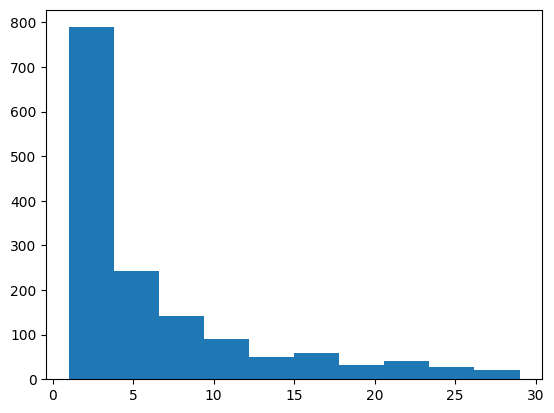

In [18]:
import matplotlib.pyplot as plt
cluster_sizes = {}
for pair in new_pairs:
    if pair['label'] in cluster_sizes.keys():
        cluster_sizes[pair['label']] += 1
    else: 
        cluster_sizes[pair['label']] = 1
sizes = np.array(list(cluster_sizes.values()))
sizes = [int(sizes[i]) for i in range(len(sizes)) if sizes[i] < 30]

print(sizes)
plt.hist(sizes)

In [19]:
day_dict_flat = {}
for i in range(len(train_scenes)):
    day_dict_flat.update(day_dict[i])

In [20]:
print(day_dict_flat[cluster_center_labeled_dict_flat[0]])

{'c_world': array([42.4258379 , 16.51018986, -2.51105356]), 'R_c2w': array([[ 0.1149658 ,  0.85357979, -0.50811849],
       [ 0.31286202, -0.51659155, -0.79702605],
       [-0.94281505, -0.06734024, -0.32644306]]), 'R_w2c_orig': array([[ 0.1149658 ,  0.31286202, -0.94281505],
       [ 0.85357979, -0.51659155, -0.06734024],
       [-0.50811849, -0.79702605, -0.32644306]]), 't_w2c_orig': array([-12.41039093, -27.85390823,  33.89668825])}


36.24292412396659
0.33544303797468356
0.15822784810126583


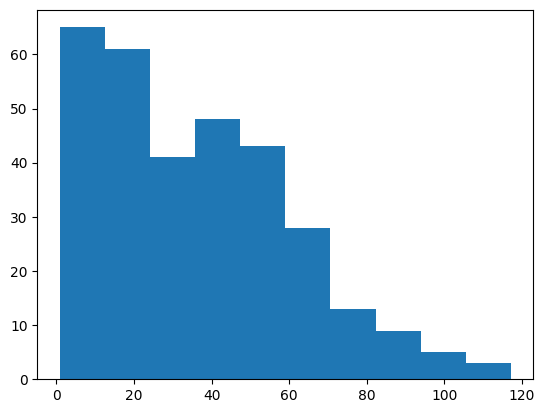

37.2273219198145
0.3333333333333333
0.17647058823529413


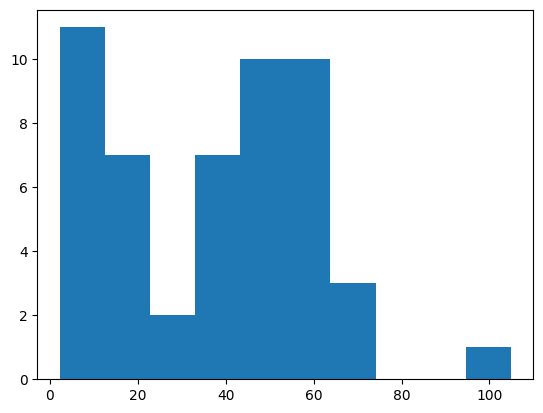

44.668759787271576
0.26666666666666666
0.1


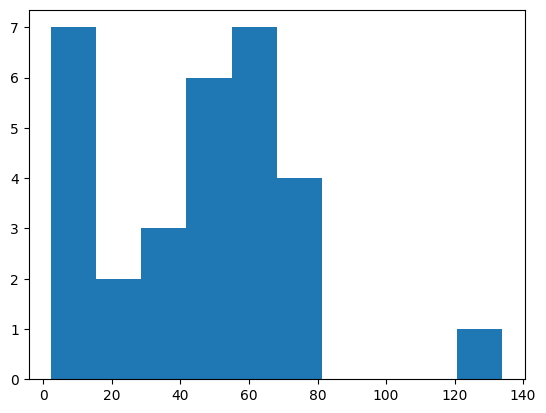

In [25]:
skips = [5, 30, 50]
dists = {}
for skip in skips:
    distances = []
    for i in range(int(NUM_TOTAL_CLASSES / skip) - 1):
        center_a = day_dict_flat[cluster_center_labeled_dict_flat[i * skip]]['c_world'] # eigentlich c_world
        center_b = day_dict_flat[cluster_center_labeled_dict_flat[(i+1) * skip]]['c_world'] # eigentlich c_world
        norm = np.linalg.norm(center_a - center_b)
        distances.append(norm)
        #print(norm)
    dists[skip] = distances



for skip in skips:
    print(np.mean(dists[skip]))
    print(np.mean(dists[skip] < 20 * np.ones_like(dists[skip])))
    print(np.mean(dists[skip] < 10 * np.ones_like(dists[skip])))
    plt.hist(dists[skip])
    plt.show()

In [30]:
print(cluster_center_labeled_dict)
print(cluster_center_labeled_dict_flat)
print(len(cluster_centers))

[{0: '320582969012.jpg', 1: '1456540571025.jpg', 2: '1561290563187.jpg', 3: '1393822171537.jpg', 4: '1281572168787.jpg', 5: '295832962050.jpg', 6: '1266322170787.jpg', 7: '1405072171125.jpg', 8: '136372684950.jpg', 9: '337082962975.jpg', 10: '339582971725.jpg', 11: '1336322166500.jpg', 12: '1188399171825.jpg', 13: '1292072170125.jpg', 14: '1502040568187.jpg', 15: '1504790566687.jpg', 16: '268332965012.jpg', 17: '1217149175825.jpg', 18: '1471290565812.jpg', 19: '1170149174612.jpg', 20: '1459540570562.jpg', 21: '1134149174187.jpg', 22: '1481290560400.jpg', 23: '133372687700.jpg', 24: '1192649169450.jpg', 25: '1113399177525.jpg', 26: '1286822170375.jpg', 27: '111600739250.jpg', 28: '314582969512.jpg', 29: '167622687950.jpg', 30: '1143399169650.jpg', 31: '288082973425.jpg', 32: '1555540566525.jpg', 33: '1381072168712.jpg', 34: '1120649166862.jpg', 35: '359332966675.jpg', 36: '1385072178787.jpg', 37: '218372693537.jpg', 38: '1203149169400.jpg', 39: '1400572174287.jpg', 40: '346332970762.jpg

Testing cluster centers 2D visualization...
Number of clusters: 1588
Number of poses in day_dict_flat: 28669
Visualizing 306 cluster centers
1282
1587


/tmp/ipykernel_11840/4230362408.py:55: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = get_cmap('viridis')  # Light to dark


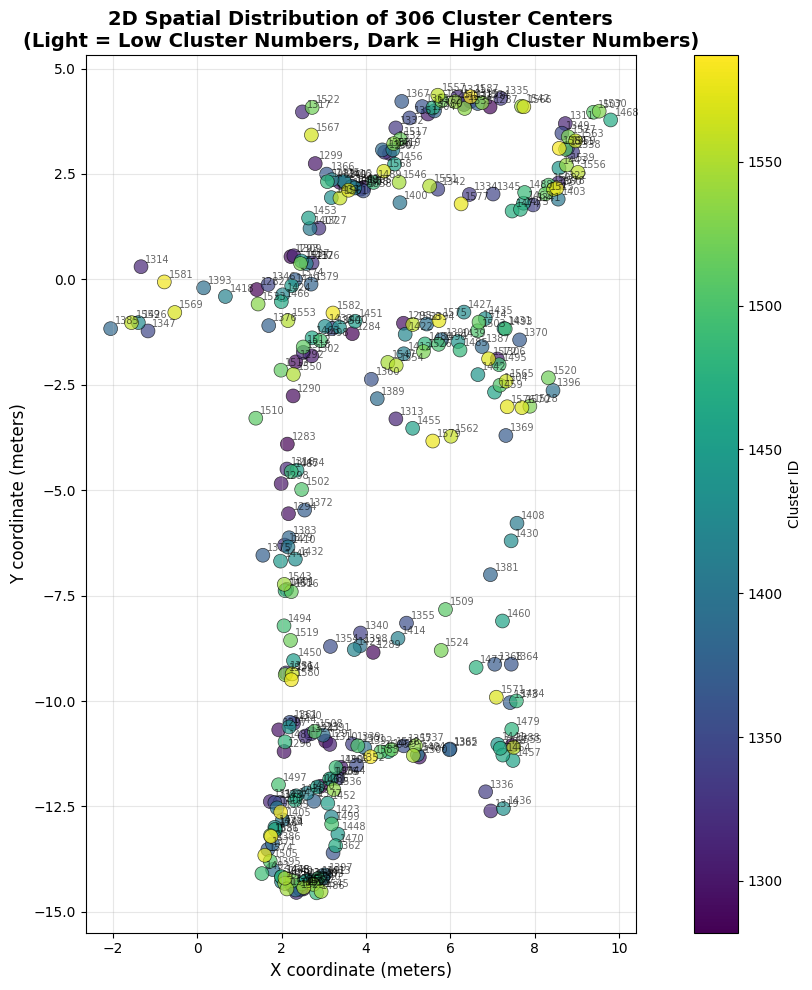


Cluster Center Statistics:
  X range: [-2.06, 9.80] meters
  Y range: [-14.55, 4.37] meters
  X span: 11.86 meters
  Y span: 18.92 meters


In [91]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.cm import get_cmap

def visualize_cluster_centers_2d(cluster_centers_dict_flat, day_dict_flat, scene_number = 0, num_classes = [0,0,0,0]):
    """
    Test: Visualize cluster centers in a 2D plane (ignoring elevation).
    
    Args:
        cluster_centers_dict_flat: Dict mapping cluster_id -> image_name (cluster center)
        day_dict_flat: Dict mapping image_name -> {'c_world': [x, y, z], ...}
    
    Returns:
        fig, ax: matplotlib figure and axes objects
    """

    min_cluster_id = 0
    max_cluster_id = 0
    for i in range(scene_number):
        min_cluster_id += num_classes[i]
    for i in range(scene_number + 1):
        max_cluster_id += num_classes[i]

    # Extract 2D coordinates for each cluster center
    cluster_coords = {}
    cluster_ids = []
    x_coords = []
    y_coords = []
    
    for cluster_id, image_name in cluster_centers_dict_flat.items():
        if image_name in day_dict_flat and cluster_id >= min_cluster_id and cluster_id <= max_cluster_id:
            pose_data = day_dict_flat[image_name]
            c_world = pose_data['c_world']  # [x, y, z]
            
            cluster_coords[cluster_id] = c_world[[0, 1]]  # Extract x, y (ignore z)
            cluster_ids.append(cluster_id)
            x_coords.append(c_world[0])
            y_coords.append(c_world[1])
    
    print(f"Visualizing {len(cluster_ids)} cluster centers")
    
    # Create figure
    fig, ax = plt.subplots(figsize=(12, 10))
    
    # Normalize cluster IDs to [0, 1] for colormap
    if len(cluster_ids) > 0:
        min_id = min(cluster_ids)
        print(min_id)
        max_id = max(cluster_ids)
        print(max_id)
        normalized_ids = [(cid - min_id) / (max_id - min_id + 1) if max_id > min_id else 0.5 
                          for cid in cluster_ids]
        
        # Use a colormap: light colors for low IDs, dark colors for high IDs
        cmap = get_cmap('viridis')  # Light to dark
        colors = [cmap(norm_id) for norm_id in normalized_ids]
        
        # Scatter plot
        scatter = ax.scatter(x_coords, y_coords, c=colors, s=100, alpha=0.7, edgecolors='black', linewidth=0.5)
        
        # Add cluster labels on the plot
        for i, cluster_id in enumerate(cluster_ids):
            ax.annotate(f'{cluster_id}', 
                       xy=(x_coords[i], y_coords[i]), 
                       xytext=(3, 3), 
                       textcoords='offset points',
                       fontsize=7,
                       alpha=0.6)
    
    ax.set_xlabel('X coordinate (meters)', fontsize=12)
    ax.set_ylabel('Y coordinate (meters)', fontsize=12)
    ax.set_title(f'2D Spatial Distribution of {len(cluster_ids)} Cluster Centers\n(Light = Low Cluster Numbers, Dark = High Cluster Numbers)', 
                 fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal')
    
    # Add colorbar
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=min_id if len(cluster_ids) > 0 else 0, 
                                                              vmax=max_id if len(cluster_ids) > 0 else 1))
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, label='Cluster ID')
    
    plt.tight_layout()
    
    return fig, ax, cluster_coords

# Test the function
print("Testing cluster centers 2D visualization...")
print(f"Number of clusters: {len(cluster_center_labeled_dict_flat)}")
print(f"Number of poses in day_dict_flat: {len(day_dict_flat)}")

fig, ax, cluster_coords = visualize_cluster_centers_2d(cluster_center_labeled_dict_flat, day_dict_flat, scene_number=3, num_classes=NUM_CLASSES)
plt.show()

# Print statistics
if len(cluster_coords) > 0:
    x_vals = [coord[0] for coord in cluster_coords.values()]
    y_vals = [coord[1] for coord in cluster_coords.values()]
    print(f"\nCluster Center Statistics:")
    print(f"  X range: [{min(x_vals):.2f}, {max(x_vals):.2f}] meters")
    print(f"  Y range: [{min(y_vals):.2f}, {max(y_vals):.2f}] meters")
    print(f"  X span: {max(x_vals) - min(x_vals):.2f} meters")
    print(f"  Y span: {max(y_vals) - min(y_vals):.2f} meters")

In [226]:
# if there are enough pairs, we can filter out pairs with large distance or angle, because they are less likely to be true matches and could add noise to the training. We can use the dist and angle values in the pairs for this. For example, we could only keep pairs with dist < 5 and angle < 10 degrees. This would be a hyperparameter that we can tune later.

day_night_pair_filtering_dist_threshold = 5.0
day_night_pair_filtering_rot_threshold = 20.0

for i in range(len(new_pairs)):
    n, d, dist, angle, label = new_pairs[i]["night_img"], new_pairs[i]["day_img"], new_pairs[i]["dist"], new_pairs[i]["angle"], new_pairs[i]["label"]
    if dist > day_night_pair_filtering_dist_threshold or angle > day_night_pair_filtering_rot_threshold:
        new_pairs[i] = None
new_pairs = [pair for pair in new_pairs if pair is not None]
print(f"Number of pairs after filtering by distance and angle: {len(new_pairs)}")

Number of pairs after filtering by distance and angle: 13027


In [20]:
print(new_pairs[500])
cluster_id = 500
filtered_dict = {k: v for k, v in day_labels.items() if v == 500}
print(filtered_dict.keys())

{'night_img': '7550900244400.jpg', 'day_img': '1296322166625.jpg', 'dist': np.float64(0.9228021029573905), 'angle': 10.004651017755902, 'label': 113}
dict_keys(['747219713225.jpg', '747469695350.jpg', '747719701800.jpg', '747969693350.jpg', '748219691062.jpg', '748469696850.jpg', '748719696100.jpg', '749219692887.jpg', '749469693387.jpg', '749719692600.jpg', '467619733875.jpg', '469619755000.jpg', '303618171000.jpg', '303868176875.jpg', '304118175250.jpg', '304868175212.jpg'])


In [34]:
import sys
import os
import copy

# 1. Den absoluten Pfad zum Repo-Wurzelverzeichnis bestimmen und hinzufügen
repo_path = os.path.abspath('VPR-methods-evaluation')
if repo_path not in sys.path:
    sys.path.append(repo_path)

from vpr_models import get_model

# 1. Day Expert initialisieren (Lädt ResNet50 mit SOTA CosPlace-Weights via Torch Hub)
print("Initialisiere Day Expert (CosPlace ResNet50)...")
day_expert = torch.hub.load(
    "gmberton/cosplace", 
    "get_trained_model", 
    backbone="ResNet50", 
    fc_output_dim=512
)

# 2. Unabhängige Kopie für den Night Expert erstellen (Deep Copy der Gewichte und Architektur)
print("Erstelle unabhängige Kopie für den Night Expert...")
night_expert = copy.deepcopy(day_expert)

day_expert.to('cuda')
night_expert.to('cuda')

# Kurzer Sanity Check: Testen, ob die Speicheradressen unterschiedlich sind
print(f"\nErfolg! Unterschiedliche Objekte im Speicher: {id(day_expert) != id(night_expert)}")

# freeze the day expert
for param in day_expert.parameters():
    param.requires_grad = False
day_expert.eval()
night_expert.train()

Initialisiere Day Expert (CosPlace ResNet50)...


Using cache found in /home/paul-hoheisel/.cache/torch/hub/gmberton_cosplace_main


Returning CosPlace model with backbone: ResNet50 with features dimension 512
Erstelle unabhängige Kopie für den Night Expert...

Erfolg! Unterschiedliche Objekte im Speicher: True


GeoLocalizationNet(
  (backbone): Sequential(
    (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (4): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Sequential(
          (0):

In [ ]:
# In deiner vpr_env ausführen: pip install torchinfo
#from torchinfo import summary

# Angenommen 'model' ist dein geladenes Backbone
# Wir simulieren einen Input von einem RGB-Bild mit 512x512 Pixeln
#summary(day_expert, input_size=(1, 3, 512, 512))

In [124]:
print(scene_images_roots)

[PosixPath('/home/paul-hoheisel/Documents/SITD-setup-and-data/day-and-night-data/aria/hb-allen-centre/ns_processed/multi/undistorted_all_valid/day_night_10/camera-rgb')
 PosixPath('/home/paul-hoheisel/Documents/SITD-setup-and-data/day-and-night-data/aria/keble-college/ns_processed/multi/undistorted_all_valid/day_night_24/camera-rgb')
 PosixPath('/home/paul-hoheisel/Documents/SITD-setup-and-data/day-and-night-data/aria/observatory-quarter/ns_processed/multi/undistorted_all_valid/day_night_25/camera-rgb')
 PosixPath('/home/paul-hoheisel/Documents/SITD-setup-and-data/day-and-night-data/aria/oxford-robotics-institute/ns_processed/multi/undistorted_all_valid/day_night_21/camera-rgb')]


Data Loading ermoeglichen

In [35]:
import os
from pathlib import Path

def build_path_mapping(image_directory):
    path_mapping = {}
    
    # Durchsucht rekursiv alle Unterordner nach jpgs (oder pngs)
    for i in range(len(train_scenes)):
        for file_path in Path(image_directory[i]).rglob("*.jpg"):
            filename = file_path.name
            
            # Schneide das Präfix ab (gleiche Logik wie bei der JSON-Extraktion)
            if '_' in filename:
                short_key = filename.split('_', 1)[1]
            else:
                short_key = filename
                
            path_mapping[short_key] = str(file_path)
        
    return path_mapping

# Führe dies EINMAL vor dem Training aus
# image_dir ist der Ordner, der die mp4-extrahieren oder ns_processed Bilder enthält
global_path_map = build_path_mapping(scene_images_roots)  # Übergib die Liste der Bildordner der Trainingsszenen

In [109]:
print(subroutes)

{0: [0, 1, 2, 4, 7, 9, 10, 11, 12, 13, 17, 19, 25, 32, 33, 48, 62, 67, 80, 90, 98, 106, 115, 118, 129, 175, 235, 238, 251, 254], 1: [3, 8, 16, 18, 22, 23, 24, 26, 30, 31, 38, 41, 43, 45, 46, 50, 51, 57, 60, 73, 94, 113, 156, 171, 200, 216, 217, 291], 2: [5, 6, 15, 28, 35, 36, 37, 42, 47, 49, 53, 61, 72, 99, 104, 108, 133, 134, 149, 166, 172, 180, 206, 237, 249, 274, 298], 3: [14, 29, 34, 39, 40, 44, 52, 58, 59, 63, 65, 66, 74, 81, 101, 116, 119, 122, 137, 151, 169, 197, 199, 208, 211, 218, 231, 236, 271], 4: [20, 21, 54, 64, 69, 70, 75, 76, 77, 83, 102, 103, 126, 131, 135, 159, 174, 191, 239, 241, 244, 252, 258, 259, 261, 311], 5: [27, 55, 56, 78, 82, 86, 93, 100, 105, 121, 124, 125, 141, 142, 146, 148, 154, 209, 224, 257, 262, 264, 278, 279, 285], 6: [68, 71, 79, 85, 88, 95, 96, 97, 107, 109, 110, 127, 140, 164, 179, 188, 204, 215, 256, 295, 309], 7: [84, 89, 112, 136, 152, 167, 170, 196, 207, 226, 247, 253, 255, 265, 288], 8: [87, 91, 114, 128, 132, 162, 177, 181, 189, 221, 245, 281,

In [43]:
from torch.utils.data import Dataset
from PIL import Image
import torchvision.transforms as T

class OxfordDayNightDataset(Dataset):
    def __init__(self, pairs, day_labels, path_map, transform=None, subroutes=None):
        """
        pairs: Liste von dicts [{'night_img': '123.jpg', 'day_img': '456.jpg'}, ...] Use new_pairs and not pairs!!
        day_labels: Dict mit den Cluster-Labels {'456.jpg': 12, ...}
        path_map: maps short path to full image path
        subroutes: Liste von Subrouten, wobei jede Subroute eine Liste von Cluster-IDs ist, die zu dieser Subroute gehören. z.B. [[0, 1, 2], [3, 4], ...]
        """
        # divide pairs into the subroutes, so that we can later sample from the subroutes during training
        if subroutes is not None:
            # Initialize pairs_by_subroute with the actual keys from subroutes dict, not range()
            pairs_by_subroute = {key: [] for key in subroutes.keys()}
            for pair in pairs:
                day_img = pair['day_img']
                day_label = day_labels[day_img]
                for subroute_id, cluster_ids in subroutes.items():
                    if day_label in cluster_ids:
                        pairs_by_subroute[subroute_id].append(pair)
                        break
            self.pairs_by_subroute = pairs_by_subroute
            print(f"pairs by subroute attribute created with {len(self.pairs_by_subroute)} subroutes.")
        self.pairs = pairs
        self.labels = day_labels
        self.path_map = path_map
        self.subroutes = subroutes
        if subroutes is not None:
            self.set_subroute(list(subroutes.keys())[0])  # Set to first subroute using actual keys

        # Standard-Transforms für ResNet (falls keine übergeben wurden)
        self.transform = transform or T.Compose([
            T.Resize((512, 512)), # Nochmal checken, ob das so Sinn macht
            T.ToTensor(),
            T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])

    def __len__(self):
        # Return length of current subroute if one is active
        if hasattr(self, 'current_pairs'):
            return len(self.current_pairs)
        elif hasattr(self, 'pairs_by_subroute'):
            return sum(len(pairs) for pairs in self.pairs_by_subroute.values())
        else:
            return len(self.pairs)
        
    def set_subroute(self, subroute_id):
        if hasattr(self, 'pairs_by_subroute') and subroute_id in self.pairs_by_subroute:
            self.current_pairs = self.pairs_by_subroute[subroute_id]
        else:
            raise ValueError(f"Ungültige Subroute-ID: {subroute_id}")

    def __getitem__(self, idx):
        if hasattr(self, 'pairs_by_subroute'):
            pair = self.current_pairs[idx]
        else:
            pair = self.pairs[idx]
        night_key = pair['night_img']
        day_key = pair['day_img']
        
        # 1. Reale Pfade nachschlagen
        night_path = self.path_map[night_key]
        day_path = self.path_map[day_key]
        
        # 2. Bilder laden (RGB, um Alpha-Kanäle etc. zu ignorieren)
        night_img = Image.open(night_path).convert('RGB')
        day_img = Image.open(day_path).convert('RGB')
        
        # 3. Tensoren erstellen
        if self.transform:
            night_img = self.transform(night_img)
            day_img = self.transform(day_img)
            
        # 4. Cluster-Label abrufen (Das Nachtbild erbt das Label des Tagbildes!)
        label = self.labels[day_key]
        
        return night_img, day_img, label

In [37]:
import torch.nn.functional as F

class LMCLoss(nn.Module):
    def __init__(self, num_classes, embedding_dim=512, margin=0.35, scale=30.0, W = None):
        super().__init__()
        self.margin = margin
        self.scale = scale
        # Das ist deine Shared Weight Matrix W (normalisiert)
        if W is not None:
            self.W = nn.Parameter(W)
            print("W was initialized by zero-shot alignment")
        else:
            self.W = nn.Parameter(torch.randn(embedding_dim, num_classes))
            print("W was initialized randomly")
        
    def forward(self, features, labels, subroute_class_indices=None):
        # Features normalisieren (L2)
        features = F.normalize(features, p=2, dim=1)

        if subroute_class_indices is not None:
            # --- HIER IST DER KNIFF ---
            # Wir schneiden uns NUR die Spalten aus W heraus, die zur Subroute gehören
            W_sub = self.W[:, subroute_class_indices]
            W_norm = F.normalize(W_sub, p=2, dim=0)
            
            # Die Logits haben jetzt nur noch die Dimension [Batch_Size, Klassen_in_Subroute] (z.B. 16 x 198)
            logits = torch.matmul(features, W_norm)
            
            # Da die Logits geschrumpft sind, stimmen die globalen Labels nicht mehr.
            # Wir müssen die globalen Labels (z.B. 0, 10, 20) auf lokale Indizes (0, 1, 2) mappen.
            mapping = {global_id: local_id for local_id, global_id in enumerate(subroute_class_indices)}
            local_labels = torch.tensor([mapping[label.item()] for label in labels], device=features.device)
            
            # Margin abziehen (auf den lokalen Indizes)
            for i in range(len(local_labels)):
                logits[i, local_labels[i]] -= self.margin
                
            return F.cross_entropy(logits * self.scale, local_labels)
        
        else:
            W_norm = F.normalize(self.W, p=2, dim=0)
            
            # Kosinus-Ähnlichkeit berechnen
            logits = torch.matmul(features, W_norm)
            
            # Margin vom Target-Logit abziehen (NocPlace Logik)
            for i in range(len(labels)):
                logits[i, labels[i]] -= self.margin
                
            # Skalieren für die Softmax
            return F.cross_entropy(logits * self.scale, labels)
    
class IKTLoss(nn.Module):
    def __init__(self, temperature=4.0):
        super().__init__()
        self.temp = temperature
        self.kl = nn.KLDivLoss(reduction="batchmean")
        
    def forward(self, night_logits, day_logits):
        # Softmax mit Temperatur auf den Lehrer (Day) anwenden
        p_day = F.softmax(day_logits / self.temp, dim=1)
        # Log-Softmax auf den Schüler (Night) anwenden
        log_p_night = F.log_softmax(night_logits / self.temp, dim=1)
        
        # KL-Divergenz berechnen und skalieren
        return self.kl(log_p_night, p_day) * (self.temp ** 2)
    
def zero_shot_alignment_of_W(train_dataset: Dataset):
    # 1. W direkt als PyTorch-Tensor auf dem richtigen Device initialisieren
    W = torch.randn(512, NUM_TOTAL_CLASSES, device=device)
    
    for c in range(NUM_TOTAL_CLASSES):
        
        # Alle Tag-Bilder für diesen Cluster finden
        day_imgs_in_cluster = [pair['day_img'] for pair in train_dataset.pairs if pair['label'] == c]
        descriptors = []
        
        for img_name in day_imgs_in_cluster:
            img_path = train_dataset.path_map[img_name]
            img = Image.open(img_path).convert('RGB')
            
            # 2. Tensor erstellen UND auf die GPU schicken (.to(device))
            img_tensor = train_dataset.transform(img).unsqueeze(0).to(device)
            
            with torch.no_grad():
                # Den Deskriptor auf der GPU belassen
                desc = day_expert(img_tensor)
                descriptors.append(desc)
        
        if descriptors:
            # 3. Mathematische Operationen direkt auf der GPU ausführen (viel schneller!)
            descriptors = torch.cat(descriptors, dim=0)  # entspricht np.vstack
            mean_descriptor = torch.mean(descriptors, dim=0)
            
            # Normalisieren
            mean_descriptor /= torch.norm(mean_descriptor) + 1e-10
            
            # Labelzuweisung im Dataset (bleibt CPU/Python)
            train_dataset.labels[day_imgs_in_cluster[0]] = c
            
            # 4. Jetzt passt es: Tensor in Tensor auf der GPU schreiben
            W[:, c] = mean_descriptor
            
    return W

In [49]:
# create pseudo subroutes with all clusters in one subroute to check the training process without subroutes first
#subroutes = {0: list(range(NUM_TOTAL_CLASSES))}
# Datensatz instanziieren 
train_dataset = OxfordDayNightDataset(
    pairs=new_pairs, 
    day_labels=day_labels, 
    path_map=global_path_map,
    subroutes=subroutes
)


In [ ]:
# 1. Reale Pfade nachschlagen
cluster_id = 500


night_path = self.path_map[night_key]
day_path = self.path_map[day_key]

# 2. Bilder laden (RGB, um Alpha-Kanäle etc. zu ignorieren)
night_img = Image.open(night_path).convert('RGB')
day_img = Image.open(day_path).convert('RGB')

[{'night_img': '5967347262287.jpg', 'day_img': '1482290562975.jpg', 'dist': np.float64(0.04374764613247462), 'angle': 4.905808442225882, 'label': 23}, {'night_img': '5968347261200.jpg', 'day_img': '1483040563312.jpg', 'dist': np.float64(0.10595582412949656), 'angle': 3.0887538081176307, 'label': 23}, {'night_img': '5968597260825.jpg', 'day_img': '1483290559312.jpg', 'dist': np.float64(0.129882988798133), 'angle': 2.6688868149554263, 'label': 23}, {'night_img': '5968847260500.jpg', 'day_img': '1483540565012.jpg', 'dist': np.float64(0.12943296238337737), 'angle': 5.874320253322244, 'label': 23}, {'night_img': '5969097260125.jpg', 'day_img': '380332975850.jpg', 'dist': np.float64(0.1908833006648588), 'angle': 5.282521672262107, 'label': 202}, {'night_img': '5969347263500.jpg', 'day_img': '380332975850.jpg', 'dist': np.float64(0.11663710762337934), 'angle': 4.764682974960079, 'label': 202}, {'night_img': '5969597263125.jpg', 'day_img': '380332975850.jpg', 'dist': np.float64(0.1623290607816

In [145]:
print(train_dataset.pairs[:5])

[{'night_img': '5967347262287.jpg', 'day_img': '1482290562975.jpg', 'dist': np.float64(0.04374764613247462), 'angle': 4.905808442225882, 'label': 23}, {'night_img': '5968347261200.jpg', 'day_img': '1483040563312.jpg', 'dist': np.float64(0.10595582412949656), 'angle': 3.0887538081176307, 'label': 23}, {'night_img': '5968597260825.jpg', 'day_img': '1483290559312.jpg', 'dist': np.float64(0.129882988798133), 'angle': 2.6688868149554263, 'label': 23}, {'night_img': '5968847260500.jpg', 'day_img': '1483540565012.jpg', 'dist': np.float64(0.12943296238337737), 'angle': 5.874320253322244, 'label': 23}, {'night_img': '5969097260125.jpg', 'day_img': '380332975850.jpg', 'dist': np.float64(0.1908833006648588), 'angle': 5.282521672262107, 'label': 202}]


In [116]:
print(f"length of subroutes: {[len(subroute) for subroute in subroutes.values()]}")

length of subroutes: [30, 28, 27, 29, 26, 25, 21, 15, 15, 16, 13, 12, 12, 7, 7, 5, 5, 6, 5, 4, 4, 1, 1, 99, 95, 92, 93, 80, 80, 63, 70, 60, 49, 46, 41, 32, 33, 31, 19, 20, 11, 14, 8, 3, 3, 5, 2, 3, 4, 2, 2, 1, 1, 1, 1, 1]


Validation method (load different scene for validation procedure)

1. load images

In [38]:
val_scene = 0
val_scene_dir = dataset_dir / all_scenes[val_scene]
val_scene_subfolder = all_scenes_image_subfoldernames[val_scene]
val_scene_images_root = val_scene_dir / f'ns_processed/multi/undistorted_all_valid/{val_scene_subfolder}/camera-rgb'
#val_day_images_root = val_scene_dir / f'ns_processed/multi/undistorted_all_valid/{all_scenes_day_subfoldernames[val_scene]}/camera-rgb'
#val_night_images_root = val_scene_dir / f'ns_processed/multi/undistorted_all_valid/{all_scenes_night_subfoldernames[val_scene]}/camera-rgb'

val_transforms_path_combined = Path(f'/home/paul-hoheisel/Documents/SITD-setup-and-data/day-and-night-data/aria/{all_scenes[val_scene]}/ns_processed/multi/undistorted_all_valid/{val_scene_subfolder}/transforms_opencv.json')

val_db_list_path = Path(f'/home/paul-hoheisel/Documents/SITD-setup-and-data/day-and-night-data/aria/{all_scenes[val_scene]}/visual_reloc/imagelists/db_imagelist.txt')
val_day_query_list_path = Path(f'/home/paul-hoheisel/Documents/SITD-setup-and-data/day-and-night-data/aria/{all_scenes[val_scene]}/visual_reloc/imagelists/query_day_imagelist.txt')
val_night_query_list_path = Path(f'/home/paul-hoheisel/Documents/SITD-setup-and-data/day-and-night-data/aria/{all_scenes[val_scene]}/visual_reloc/imagelists/query_night_imagelist.txt')

In [39]:
print(f"Val DB List Path: {val_db_list_path}")

Val DB List Path: /home/paul-hoheisel/Documents/SITD-setup-and-data/day-and-night-data/aria/bodleian-library/visual_reloc/imagelists/db_imagelist.txt


In [40]:
def load_gt_poses(txt_path, json_path):
    """
    Load ground truth poses for images listed in txt file.
    
    Args:
        txt_path: Path to txt file containing image names/paths (one per line, prefixed with "camera-rgb/")
        json_path: Path to JSON file (transforms_opencv.json) containing pose information
        
    Returns:
        poses: Dict mapping clean_image_name -> {'q': quaternion (qw, qx, qy, qz), 't': translation}
    """
    from scipy.spatial.transform import Rotation as R_scipy
    
    # 1. Load image names from txt file
    with open(txt_path, 'r') as f:
        lines = f.readlines()
    
    image_names_from_txt = set()
    for line in lines[3:]:  # Skip header lines
        line = line.strip()
        if not line:
            continue
        # Extract just the filename (remove "camera-rgb/" prefix if present)
        if '/' in line:
            image_name = line.split('/')[-1]  # "vrs00_123456789.jpg"
        else:
            image_name = line
        
        # Clean name (remove vrs prefix to match JSON)
        if '_' in image_name:
            clean_name = image_name.split('_', 1)[1]  # "123456789.jpg"
        else:
            clean_name = image_name
        
        image_names_from_txt.add(clean_name)
    
    print(f"Loaded {len(image_names_from_txt)} image names from {Path(txt_path).name}")
    
    # 2. Load poses from JSON file
    with open(json_path, 'r') as f:
        data = json.load(f)
    
    poses = {}
    counter = 0
    
    for frame in data['frames']:
        full_path = frame['file_path']
        raw_name = full_path.split('/')[-1]  # "vrs00_59673489879.jpg"
        
        if '_' in raw_name:
            clean_name = raw_name.split('_', 1)[1]  # "59673489879.jpg"
        else:
            clean_name = raw_name
        
        # Only keep poses for images that are in the txt file
        if clean_name not in image_names_from_txt:
            continue
        
        # Extract pose information from transform_matrix
        matrix = np.array(frame['transform_matrix'])
        R_w2c = matrix[0:3, 0:3]
        t_w2c = matrix[0:3, 3]
        
        # Convert rotation matrix to quaternion [qw, qx, qy, qz]
        R_quat = R_scipy.from_matrix(R_w2c)
        q_array = R_quat.as_quat()  # Returns [qx, qy, qz, qw]
        q = np.array([q_array[3], q_array[0], q_array[1], q_array[2]])  # Reorder to [qw, qx, qy, qz]
        
        t = t_w2c
        
        poses[clean_name] = {'q': q, 't': t}
        
        if counter < 3:  # Print the first loaded poses for verification
            print(f"  Loaded pose for: {clean_name}")
            print(f"    Quaternion: {q}")
            print(f"    Translation: {t}")
            counter += 1
    
    print(f"  Total poses matched: {len(poses)}\n")
    return poses

val_db_poses = load_gt_poses(val_db_list_path, val_transforms_path_combined)
val_day_query_poses = load_gt_poses(val_day_query_list_path, val_transforms_path_combined)
val_night_query_poses = load_gt_poses(val_night_query_list_path, val_transforms_path_combined)

Loaded 2539 image names from db_imagelist.txt
  Loaded pose for: 419597286850.jpg
    Quaternion: [ 0.61930255 -0.36609209 -0.57355447  0.39176039]
    Translation: [ -5.08625268 138.04553262 -68.2742539 ]
  Loaded pose for: 421097295475.jpg
    Quaternion: [-0.64920264  0.24554495  0.6898518  -0.20578656]
    Translation: [  4.7685661  154.62129457   1.6702887 ]
  Loaded pose for: 421847287100.jpg
    Quaternion: [-0.66765493  0.01531884  0.74399277  0.02183976]
    Translation: [ -4.33606747 121.88717636  95.08381007]
  Total poses matched: 2539

Loaded 1307 image names from query_day_imagelist.txt
  Loaded pose for: 436347290800.jpg
    Quaternion: [-0.65448235  0.23673879  0.67412668 -0.24730712]
    Translation: [ -3.58852583 157.06789305 -22.18033066]
  Loaded pose for: 440597284050.jpg
    Quaternion: [-0.51574264  0.51356114  0.53930617 -0.42357212]
    Translation: [  20.64277539   95.93837803 -126.35031453]
  Loaded pose for: 441347285600.jpg
    Quaternion: [-0.4388562   0.5

In [41]:
def build_path_mapping_for_validation(image_directory):
    path_mapping = {}
    
    # Durchsucht rekursiv alle Unterordner nach jpgs (oder pngs)

    for file_path in Path(image_directory).rglob("*.jpg"):
        filename = file_path.name
        
        # Schneide das Präfix ab (gleiche Logik wie bei der JSON-Extraktion)
        if '_' in filename:
            short_key = filename.split('_', 1)[1]
        else:
            short_key = filename
            
        path_mapping[short_key] = str(file_path)
        
    return path_mapping

In [44]:
# Build validation path mapping (maps image names to full file paths)
print(f"Building validation path mapping for images in {val_scene_images_root}...")
val_path_map = build_path_mapping_for_validation(str(val_scene_images_root))
print(f"Validation path mapping: {len(val_path_map)} images found in {val_scene_images_root}")

# Verify some paths
if len(val_path_map) > 0:
    sample_keys = list(val_path_map.keys())[:3]
    for key in sample_keys:
        print(f"  Sample: {key} -> {val_path_map[key]}")


Building validation path mapping for images in /home/paul-hoheisel/Documents/SITD-setup-and-data/day-and-night-data/aria/bodleian-library/ns_processed/multi/undistorted_all_valid/day_night_44/camera-rgb...
Validation path mapping: 41081 images found in /home/paul-hoheisel/Documents/SITD-setup-and-data/day-and-night-data/aria/bodleian-library/ns_processed/multi/undistorted_all_valid/day_night_44/camera-rgb
  Sample: 1331390742450.jpg -> /home/paul-hoheisel/Documents/SITD-setup-and-data/day-and-night-data/aria/bodleian-library/ns_processed/multi/undistorted_all_valid/day_night_44/camera-rgb/vrs00_1331390742450.jpg
  Sample: 389598375212.jpg -> /home/paul-hoheisel/Documents/SITD-setup-and-data/day-and-night-data/aria/bodleian-library/ns_processed/multi/undistorted_all_valid/day_night_44/camera-rgb/vrs24_389598375212.jpg
  Sample: 2819354403925.jpg -> /home/paul-hoheisel/Documents/SITD-setup-and-data/day-and-night-data/aria/bodleian-library/ns_processed/multi/undistorted_all_valid/day_nigh

In [45]:
from torch.utils.data import DataLoader

class ValidationDataset(Dataset):
    """
    Validation dataset für Localization-Evaluierung
    Laden von Bildern (DB / Query) mit ihren Ground-Truth Posen
    """
    def __init__(self, image_names, poses_dict, path_map, transform=None):
        """
        image_names: Liste von Bildnamen (werden als Keys in path_map nachgeschlagen)
        poses_dict: Dict mit poses für diese Bilder {'img_name': {'q': quat, 't': trans}}
        path_map: Maps image_name -> full_file_path
        transform: Optional Transformationen (default: ResNet normalisiert)
        """
        self.image_names = image_names
        self.poses = poses_dict
        self.path_map = path_map
        
        self.transform = transform or T.Compose([
            T.Resize((512, 512)),
            T.ToTensor(),
            T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])
    
    def __len__(self):
        return len(self.image_names)
    
    def __getitem__(self, idx):
        img_name = self.image_names[idx]
        
        # Lade Bild
        img_path = self.path_map[img_name]
        img = Image.open(img_path).convert('RGB')
        
        if self.transform:
            img = self.transform(img)
        
        # Hole Pose
        pose = self.poses[img_name]
        
        return {
            'image': img,
            'image_name': img_name,
            'quaternion': torch.tensor(pose['q'], dtype=torch.float32),
            'translation': torch.tensor(pose['t'], dtype=torch.float32)
        }


# Extrahiere Bildnamen aus den geladenen Posen
val_db_image_names = list(val_db_poses.keys())
val_day_query_image_names = list(val_day_query_poses.keys())
val_night_query_image_names = list(val_night_query_poses.keys())

print(f"\nValidation Dataset Summary:")
print(f"  Database Images: {len(val_db_image_names)}")
print(f"  Day Query Images: {len(val_day_query_image_names)}")
print(f"  Night Query Images: {len(val_night_query_image_names)}")

# Erstelle Validation Datasets
val_db_dataset = ValidationDataset(
    image_names=val_db_image_names,
    poses_dict=val_db_poses,
    path_map=val_path_map
)

val_day_query_dataset = ValidationDataset(
    image_names=val_day_query_image_names,
    poses_dict=val_day_query_poses,
    path_map=val_path_map
)

val_night_query_dataset = ValidationDataset(
    image_names=val_night_query_image_names,
    poses_dict=val_night_query_poses,
    path_map=val_path_map
)

print(f"  ✓ ValidationDatasets created successfully")

# Erstelle DataLoaders (kein Shuffling, kein Multi-Processing für Validation)
val_db_loader = DataLoader(val_db_dataset, batch_size=32, shuffle=False, num_workers=0)
val_day_query_loader = DataLoader(val_day_query_dataset, batch_size=32, shuffle=False, num_workers=0)
val_night_query_loader = DataLoader(val_night_query_dataset, batch_size=32, shuffle=False, num_workers=0)

print(f"  ✓ DataLoaders created")
print(f"    - DB Loader: {len(val_db_loader)} batches")
print(f"    - Day Query Loader: {len(val_day_query_loader)} batches")
print(f"    - Night Query Loader: {len(val_night_query_loader)} batches")



Validation Dataset Summary:
  Database Images: 2539
  Day Query Images: 1307
  Night Query Images: 2905
  ✓ ValidationDatasets created successfully
  ✓ DataLoaders created
    - DB Loader: 80 batches
    - Day Query Loader: 41 batches
    - Night Query Loader: 91 batches


In [46]:
def compute_embeddings(model, dataloader, device):
    """
    Compute embeddings für alle Bilder in einem DataLoader
    Gibt zurück: embeddings (N, 512), image_names, poses
    """
    all_embeddings = []
    all_image_names = []
    all_quaternions = []
    all_translations = []
    
    model.eval()
    with torch.no_grad():
        for batch in dataloader:
            images = batch['image'].to(device)
            
            # Compute embeddings
            embeddings = model(images)
            
            all_embeddings.append(embeddings.cpu())
            all_image_names.extend(batch['image_name'])
            all_quaternions.append(batch['quaternion'].cpu())
            all_translations.append(batch['translation'].cpu())
    
    embeddings = torch.cat(all_embeddings, dim=0)  # (N, 512)
    quaternions = torch.cat(all_quaternions, dim=0)  # (N, 4)
    translations = torch.cat(all_translations, dim=0)  # (N, 3)
    
    return embeddings, all_image_names, quaternions, translations


def evaluate_localization(query_embeddings, query_image_names, db_embeddings, db_image_names, 
                          query_poses, db_poses, top_k=5):
    """
    Einfache Nearest-Neighbor Localization Evaluierung
    Compute recall@K: Wie oft ist die Ground-Truth DB-Image in den Top-K Retrievals
    
    Args:
        query_embeddings: (N_q, 512)
        db_embeddings: (N_db, 512)
        query_poses, db_poses: Dicts mit Posen
        top_k: Nur Top-K NNs für Recall berechnen
    
    Returns:
        recalls: Dict mit Recall@1, Recall@5, etc.
    """
    # L2-normalize embeddings
    query_emb_norm = F.normalize(query_embeddings, p=2, dim=1)
    db_emb_norm = F.normalize(db_embeddings, p=2, dim=1)
    
    # Compute similarities: (N_q, N_db)
    similarities = torch.matmul(query_emb_norm, db_emb_norm.t())
    
    # Get Top-K
    _, top_k_indices = torch.topk(similarities, k=top_k, dim=1)  # (N_q, k)
    
    # Evaluate
    recalls = {1: 0, 5: 0, 10: 0}
    
    for q_idx in range(len(query_image_names)):
        q_name = query_image_names[q_idx]
        q_pos = query_poses[q_name]
        q_trans = np.array(q_pos['t'])
        
        # Threshold für korrektes Match (z.B. 25 Meter) TODO: angle fehlt, aber fuer die Benchmarks gar nicht so relevant
        dist_threshold = 25.0
        
        for rank, db_idx in enumerate(top_k_indices[q_idx].tolist()):
            db_name = db_image_names[db_idx]
            db_pos = db_poses[db_name]
            db_trans = np.array(db_pos['t'])
            
            dist = np.linalg.norm(q_trans - db_trans)
            
            if dist < dist_threshold:
                if rank < 1:
                    recalls[1] += 1
                if rank < 5:
                    recalls[5] += 1
                if rank < 10:
                    recalls[10] += 1
                break
    
    # Normalisiere
    n_queries = len(query_image_names)
    recalls[1] = (recalls[1] / n_queries * 100) if n_queries > 0 else 0
    recalls[5] = (recalls[5] / n_queries * 100) if n_queries > 0 else 0
    recalls[10] = (recalls[10] / n_queries * 100) if n_queries > 0 else 0
    
    return recalls


print("✓ Validation helper functions created (compute_embeddings, evaluate_localization)")


✓ Validation helper functions created (compute_embeddings, evaluate_localization)


In [47]:
def validate_during_training(model, val_db_loader, val_day_query_loader, val_night_query_loader, 
                             val_db_image_names, val_day_query_image_names, val_night_query_image_names,
                             val_db_poses, val_day_query_poses, val_night_query_poses,
                             device, epoch):
    """
    Validierungsfunktion zum Aufrufen während des Trainings
    Berechnet Recall@1 und Recall@5 für Day und Night Query Bilder
    """
    print(f"\n{'='*60}")
    print(f"Validation nach Epoch {epoch}")
    print(f"{'='*60}")
    
    # Compute embeddings für alle Splits
    print("  Computing embeddings for database...")
    db_emb, _, _, _ = compute_embeddings(model, val_db_loader, device)
    
    print("  Computing embeddings for day queries...")
    day_query_emb, _, _, _ = compute_embeddings(model, val_day_query_loader, device)
    
    print("  Computing embeddings for night queries...")
    night_query_emb, _, _, _ = compute_embeddings(model, val_night_query_loader, device)
    
    # Evaluate Day Queries
    print("\n  Evaluating Day Queries...")
    day_recalls = evaluate_localization(
        query_embeddings=day_query_emb,
        query_image_names=val_day_query_image_names,
        db_embeddings=db_emb,
        db_image_names=val_db_image_names,
        query_poses=val_day_query_poses,
        db_poses=val_db_poses,
        top_k=10
    )
    
    # Evaluate Night Queries
    print("  Evaluating Night Queries...")
    night_recalls = evaluate_localization(
        query_embeddings=night_query_emb,
        query_image_names=val_night_query_image_names,
        db_embeddings=db_emb,
        db_image_names=val_db_image_names,
        query_poses=val_night_query_poses,
        db_poses=val_db_poses,
        top_k=10
    )
    
    # Print Results
    print(f"\n  Day Queries:")
    print(f"    Recall@1: {day_recalls[1]:.2f}%")
    print(f"    Recall@5: {day_recalls[5]:.2f}%")
    print(f"    Recall@10: {day_recalls[10]:.2f}%")
    
    print(f"\n  Night Queries:")
    print(f"    Recall@1: {night_recalls[1]:.2f}%")
    print(f"    Recall@5: {night_recalls[5]:.2f}%")
    print(f"    Recall@10: {night_recalls[10]:.2f}%")
    
    print(f"{'='*60}\n")
    
    return {
        'day_recall_1': day_recalls[1],
        'day_recall_5': day_recalls[5],
        'day_recall_10': day_recalls[10],
        'night_recall_1': night_recalls[1],
        'night_recall_5': night_recalls[5],
        'night_recall_10': night_recalls[10]
    }


print("✓ validate_during_training function ready")
print("\nUsage during training:")
print("  val_results = validate_during_training(")
print("      model=night_expert,")
print("      val_db_loader=val_db_loader,")
print("      val_day_query_loader=val_day_query_loader,")
print("      val_night_query_loader=val_night_query_loader,")
print("      val_db_image_names=val_db_image_names,")
print("      val_day_query_image_names=val_day_query_image_names,")
print("      val_night_query_image_names=val_night_query_image_names,")
print("      val_db_poses=val_db_poses,")
print("      val_day_query_poses=val_day_query_poses,")
print("      val_night_query_poses=val_night_query_poses,")
print("      device=device,")
print("      epoch=epoch_number")
print("  )")


✓ validate_during_training function ready

Usage during training:
  val_results = validate_during_training(
      model=night_expert,
      val_db_loader=val_db_loader,
      val_day_query_loader=val_day_query_loader,
      val_night_query_loader=val_night_query_loader,
      val_db_image_names=val_db_image_names,
      val_day_query_image_names=val_day_query_image_names,
      val_night_query_image_names=val_night_query_image_names,
      val_db_poses=val_db_poses,
      val_day_query_poses=val_day_query_poses,
      val_night_query_poses=val_night_query_poses,
      device=device,
      epoch=epoch_number
  )


In [50]:
from torch.utils.data import DataLoader
from torch.optim import SGD

W = zero_shot_alignment_of_W(train_dataset)

# DataLoader mit Multi-Processing (num_workers) für schnelles Laden
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=4)

# Initialisiere beide Module EINMAL vor der Schleife
lmc_module = LMCLoss(num_classes=NUM_CLASSES, W=W).to(device)
ikt_module = IKTLoss().to(device)

# Optimizer Setup: Nur Night Expert wird trainiert
optimizer = SGD(night_expert.parameters(), lr=0.001, momentum=0.9)

# Hyperparameter
#alpha = 10.0  # bzw. 50.0 beim zweiten Run
#num_epochs = 1
compute_benchmark = False


if compute_benchmark:
    # Compute benchmark on validation scene using loaded day_expert
   
    print("COMPUTING BENCHMARK ON VALIDATION SCENE")
    

    # Verify model is available
    if 'day_expert' not in locals():
        print("ERROR: day_expert model not found. Please ensure training is completed first.")
    else:
        # Run validation
        val_results = validate_during_training(
            model=day_expert,
            val_db_loader=val_db_loader,
            val_day_query_loader=val_day_query_loader,
            val_night_query_loader=val_night_query_loader,
            val_db_image_names=val_db_image_names,
            val_day_query_image_names=val_day_query_image_names,
            val_night_query_image_names=val_night_query_image_names,
            val_db_poses=val_db_poses,
            val_day_query_poses=val_day_query_poses,
            val_night_query_poses=val_night_query_poses,
            device=device,
            epoch='FINAL'
        )



print(f"\n{'='*60}")
print(f"Training-Setup:")
print(f"  Dataset Größe: {len(train_dataset)} Sample Pairs")
print(f"  Anzahl Cluster (Klassen): {NUM_CLASSES}")
print(f" Gesamtanzahl Clusters: {NUM_TOTAL_CLASSES}")
print(f"  Batch Größe: 16")
print(f"  Device: {device}")
print(f"  Alpha (IKT Weight): {alpha}")

print(f"spatial_filtering_dist_threshold: {spatial_filtering_dist_threshold}m")
print(f"spatial_filtering_rot_threshold: {spatial_filtering_rot_threshold}°")
print(f"location_clustering_dist_threshold: {location_clustering_dist_threshold}m")
print(f"location_clustering_rot_weight: {location_clustering_rot_weight}°")
print(f"day_night_pairing_dist_threshold: {day_night_pairing_dist_threshold}m")
print(f"day_night_pairing_rot_threshold: {day_night_pairing_rot_threshold}°")
print(f"num_epochs: {num_epochs}")

print(f"{'='*60}\n")

if subroutes is not None:
    num_subroutes = len(subroutes)
    print(f"Anzahl Subrouten: {num_subroutes}")
    subroute_order = list(range(num_subroutes))  # z.B. [0, 1, 2, 3] für 4 Subrouten

for epoch in range(num_epochs):
    print(f"Epoch {epoch+1}/{num_epochs}")

    # new part
    if subroutes is not None:
        np.random.shuffle(subroute_order)
    
        for subroute_idx in subroute_order:
            # 1. Das Dataset auf die aktuelle Subroute umstellen
            train_dataset.set_subroute(list(subroutes.keys())[subroute_idx])
            
            # 2. Den DataLoader neu aufsetzen (kostet in PyTorch keine Zeit)
            # Dadurch werden die internen Indizes für diese Subroute frisch generiert
            train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, drop_last=True)




        
            for batch_idx, (img_night, img_day, labels) in enumerate(train_loader):
                img_night = img_night.to(device)
                img_day = img_day.to(device)
                labels = labels.to(device)
                
                if batch_idx == 0:
                    print(f"  Batch 1 | Shape - Night: {img_night.shape}, Day: {img_day.shape}, Labels: {labels.shape}")
                
                # 1. Feature Extraction
                with torch.no_grad():
                    feats_day = day_expert(img_day)  
                feats_night = night_expert(img_night)

                if batch_idx == 0:
                    print(f"          | Features - Night: {feats_night.shape}, Day: {feats_day.shape}")

                # 2. Logits via Shared Matrix W generieren
                W_norm = F.normalize(lmc_module.W, p=2, dim=0)
                logits_day = torch.matmul(F.normalize(feats_day, p=2, dim=1), W_norm)
                logits_night = torch.matmul(F.normalize(feats_night, p=2, dim=1), W_norm)

                # 3. Losses berechnen
                loss_lmc = lmc_module(feats_night, labels)
                loss_ikt = ikt_module(logits_night, logits_day)

                # Total Loss nach NocPlace-Formel
                total_loss = loss_lmc + alpha * loss_ikt

                # 4. Backward Pass
                optimizer.zero_grad()
                total_loss.backward()
                optimizer.step()






                # Debugging: Prints nach jedem 5. Batch
                if batch_idx % 5 == 0:
                    print(f"  Batch {batch_idx+1:3d} | LMC Loss: {loss_lmc.item():.6f} | IKT Loss: {loss_ikt.item():.6f} | Total: {total_loss.item():.6f}")
                
                # Nur beim allerersten Batch: Mehr Details
                if batch_idx == 0:
                    print(f"          | Label-Verteilung: min={labels.min().item()}, max={labels.max().item()}")
    else:
        
        train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, drop_last=True)





        for batch_idx, (img_night, img_day, labels) in enumerate(train_loader):
            img_night = img_night.to(device)
            img_day = img_day.to(device)
            labels = labels.to(device)
            
            if batch_idx == 0:
                print(f"  Batch 1 | Shape - Night: {img_night.shape}, Day: {img_day.shape}, Labels: {labels.shape}")
            
            # 1. Feature Extraction
            with torch.no_grad():
                feats_day = day_expert(img_day)  
            feats_night = night_expert(img_night)

            if batch_idx == 0:
                print(f"          | Features - Night: {feats_night.shape}, Day: {feats_day.shape}")

            # 2. Logits via Shared Matrix W generieren
            W_norm = F.normalize(lmc_module.W, p=2, dim=0)
            logits_day = torch.matmul(F.normalize(feats_day, p=2, dim=1), W_norm)
            logits_night = torch.matmul(F.normalize(feats_night, p=2, dim=1), W_norm)

            # 3. Losses berechnen
            loss_lmc = lmc_module(feats_night, labels)
            loss_ikt = ikt_module(logits_night, logits_day)

            # Total Loss nach NocPlace-Formel
            total_loss = loss_lmc + alpha * loss_ikt

            # 4. Backward Pass
            optimizer.zero_grad()
            total_loss.backward()
            optimizer.step()






            # Debugging: Prints nach jedem 5. Batch
            if batch_idx % 5 == 0:
                print(f"  Batch {batch_idx+1:3d} | LMC Loss: {loss_lmc.item():.6f} | IKT Loss: {loss_ikt.item():.6f} | Total: {total_loss.item():.6f}")
            
            # Nur beim allerersten Batch: Mehr Details
            if batch_idx == 0:
                print(f"          | Label-Verteilung: min={labels.min().item()}, max={labels.max().item()}")


    # NEU
    val_results = validate_during_training(
        model=night_expert,
        val_db_loader=val_db_loader,
        val_day_query_loader=val_day_query_loader,
        val_night_query_loader=val_night_query_loader,
        val_db_image_names=val_db_image_names,
        val_day_query_image_names=val_day_query_image_names,
        val_night_query_image_names=val_night_query_image_names,
        val_db_poses=val_db_poses,
        val_day_query_poses=val_day_query_poses,
        val_night_query_poses=val_night_query_poses,
        device=device,
        epoch=epoch
    )





    print(f"Evaluiere cluster assignment accuracy auf training set nach Epoch {epoch+1}...")
    predicted_labels = []
    true_labels = []
    for img_night, img_day, labels in train_loader:
        img_night = img_night.to(device)
        img_day = img_day.to(device)
        labels = labels.to(device)
        
        with torch.no_grad():
            feats_night = night_expert(img_night)
            W_norm = F.normalize(lmc_module.W, p=2, dim=0)
            logits_night = torch.matmul(F.normalize(feats_night, p=2, dim=1), W_norm)
            preds = torch.argmax(logits_night, dim=1)
            predicted_labels.extend(preds.cpu().numpy())
            true_labels.extend(labels.cpu().numpy())
    predicted_labels = np.array(predicted_labels)
    true_labels = np.array(true_labels)
    accuracy = np.mean(predicted_labels == true_labels)
    print(f"  Cluster Assignment Accuracy auf Training Set: {accuracy*100:.2f}%\n")


W was initialized by zero-shot alignment

Training-Setup:
  Dataset Größe: 13127 Sample Pairs
  Anzahl Cluster (Klassen): [151, 621, 507, 321]
 Gesamtanzahl Clusters: 1600
  Batch Größe: 16
  Device: cuda
  Alpha (IKT Weight): 10.0
spatial_filtering_dist_threshold: 0.1m
spatial_filtering_rot_threshold: 3.0°
location_clustering_dist_threshold: 1.5m
location_clustering_rot_weight: 1.0°
day_night_pairing_dist_threshold: 3.0m
day_night_pairing_rot_threshold: 5.0°
num_epochs: 1

Epoch 1/1
  Batch 1 | Shape - Night: torch.Size([16, 3, 512, 512]), Day: torch.Size([16, 3, 512, 512]), Labels: torch.Size([16])
          | Features - Night: torch.Size([16, 512]), Day: torch.Size([16, 512])
  Batch   1 | LMC Loss: 14.865813 | IKT Loss: 0.005033 | Total: 14.916146
          | Label-Verteilung: min=0, max=1380
  Batch   6 | LMC Loss: 19.296179 | IKT Loss: 0.010274 | Total: 19.398916
  Batch  11 | LMC Loss: 18.290894 | IKT Loss: 0.004861 | Total: 18.339499
  Batch  16 | LMC Loss: 17.176340 | IKT Loss

In [55]:
print(cluster_centers)

['132184795475.jpg', '106708179137.jpg', '273848314875.jpg', '336121342100.jpg', '321348313300.jpg', '71458179212.jpg', '331120760750.jpg', '180099960537.jpg', '215599236750.jpg', '126208177800.jpg', '180458174962.jpg', '209892349400.jpg', '266120774750.jpg', '356368679287.jpg', '450098454725.jpg', '244099239162.jpg', '31208185212.jpg', '220349236250.jpg', '269099226837.jpg', '84684800812.jpg', '347848308675.jpg', '211848322587.jpg', '392118682412.jpg', '203392345150.jpg', '175099970412.jpg', '257848321337.jpg', '417848461600.jpg', '97958183175.jpg', '335868681212.jpg', '227349229750.jpg', '250598349800.jpg', '234098315087.jpg', '337620769875.jpg', '438098465475.jpg', '403368680712.jpg', '227149972212.jpg', '172889378887.jpg', '247848313212.jpg', '262870760375.jpg', '368848317125.jpg', '313371340187.jpg', '153599971662.jpg', '300349234962.jpg', '208392347487.jpg', '280199962875.jpg', '253848315675.jpg', '83708180012.jpg', '405618677587.jpg', '251870764912.jpg', '154708185087.jpg', '434

Compute benchmark for VPR based on normal CosPlace


-
-
-
Tests
-
-
-


In [16]:
# count the number of clusters with at least one night image
clusters_with_night = set(night_labels.values())
print(f"Number of clusters with at least one night image: {len(clusters_with_night)} out of {len(set(day_labels.values()))} total clusters.")
# print the number of night images assigned to each cluster
from collections import Counter
night_cluster_counts = Counter(night_labels.values())
for cluster_id, count in night_cluster_counts.items():
    print(f"Cluster {cluster_id}: {count} night images")

Number of clusters with at least one night image: 2957 out of 2957 total clusters.
Cluster 232: 9 night images
Cluster 78: 1 night images
Cluster 280: 3 night images
Cluster 350: 1 night images
Cluster 82: 4 night images
Cluster 300: 3 night images
Cluster 63: 1 night images
Cluster 97: 1 night images
Cluster 101: 6 night images
Cluster 107: 3 night images
Cluster 3: 2 night images
Cluster 109: 1 night images
Cluster 46: 2 night images
Cluster 22: 15 night images
Cluster 201: 3 night images
Cluster 246: 10 night images
Cluster 23: 6 night images
Cluster 15: 23 night images
Cluster 155: 16 night images
Cluster 285: 7 night images
Cluster 329: 10 night images
Cluster 249: 7 night images
Cluster 145: 1 night images
Cluster 26: 7 night images
Cluster 304: 3 night images
Cluster 62: 2 night images
Cluster 92: 4 night images
Cluster 93: 28 night images
Cluster 89: 9 night images
Cluster 21: 8 night images
Cluster 279: 6 night images
Cluster 79: 7 night images
Cluster 5: 113 night images
Clus

In [17]:
# test dict access
print(day_dict[day_image_names[0]]['c_world'])
print(day_dict[day_image_names[0]]['R_c2w'])
print(night_dict[night_image_names[0]]['c_world'])
print(night_dict[night_image_names[0]]['R_c2w'])
print(day_dict[day_image_names[0]])

TypeError: list indices must be integers or slices, not list

In [120]:
# Show a few pairs
random_indices = np.random.choice(len(pairs), size=min(3, len(pairs)), replace=False)
random_indices = [100, 101, 102] if len(pairs) >= 3 else list(range(len(pairs)))  # For reproducibility in this example
for i in random_indices:
    print(f"Pair {i+1}: Night Image: {pairs[i][0]}, Day Image: {pairs[i][1]}, Distance: {pairs[i][2]:.2f}, Angle Diff: {pairs[i][3]:.2f}°, Cluster ID: {pairs[i][4]}")
    # Show images, you have to adjust the paths based on your setup: the vrs** info is lost in the clean_name, so we need to find the corresponding file in the folder
    # look for the night image file
    night_img_path = None
    for file in night_images_root.glob('*.jpg'):
        if file.name.endswith(pairs[i][0]):
            night_img_path = file
            break
    # look for the day image file
    day_img_path = None 
    for file in day_images_root.glob('*.jpg'):
        if file.name.endswith(pairs[i][1]):
            day_img_path = file
            break
    # show jpg images
    from PIL import Image
    import matplotlib.pyplot as plt
    night_img = Image.open(night_img_path)
    day_img = Image.open(day_img_path)
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(night_img)
    plt.title(f"Night: {pairs[i][0]}")
    plt.axis('off')
    plt.subplot(1, 2, 2)
    plt.imshow(day_img)
    plt.title(f"Day: {pairs[i][1]}")
    plt.axis('off')
    plt.show()

IndexError: list index out of range

In [ ]:
# show all images of cluster 0
cluster_index = pairs[0][4]  # Cluster ID des ersten Paares

cluster_0_day_images = [name for name, label in day_labels.items() if label == cluster_index]
print(f"Cluster 0 contains {len(cluster_0_day_images)} day images.")
for img_name in cluster_0_day_images:
    print(f"translation of {img_name}: ", day_dict[img_name]['c_world'])
    img_path = None
    for file in day_images_root.glob('*.jpg'):
        if file.name.endswith(img_name):
            img_path = file
            break
    img = Image.open(img_path)
    plt.imshow(img)
    plt.title(f"Cluster 0: {img_name}")
    plt.axis('off')
    plt.show()


cluster_0_night_images = [name for name, label in night_labels.items() if label == cluster_index]
print(f"Cluster 0 contains {len(cluster_0_night_images)} night images.")
for img_name in cluster_0_night_images:
    print(f"translation of {img_name}: ", night_dict[img_name]['c_world'])
    img_path = None
    for file in night_images_root.glob('*.jpg'):
        if file.name.endswith(img_name):
            img_path = file
            break
    img = Image.open(img_path)
    plt.imshow(img)
    plt.title(f"Cluster 0: {img_name}")
    plt.axis('off')
    plt.show()

In [82]:
# Find a day and a night image with similar translation and rotation (small distance and angle difference) and show them side by side
n = 5
random_indices = np.random.choice(len(pairs), size=min(n, len(pairs)), replace=False)
for i in random_indices:
    if(pairs[i][2] < 1.0 and pairs[i][3] < 5.0):
        print(f"Pair {i+1}: Night Image: {pairs[i][0]}, Day Image: {pairs[i][1]}, Distance: {pairs[i][2]:.2f}, Angle Diff: {pairs[i][3]:.2f}°")
        # Show images
        night_img_path = None
        for file in night_images_root.glob('*.jpg'):
            if file.name.endswith(pairs[i][0]):
                night_img_path = file
                break
        day_img_path = None
        for file in day_images_root.glob('*.jpg'):
            if file.name.endswith(pairs[i][1]):
                day_img_path = file
                break
        # show jpg images
        night_img = Image.open(night_img_path)
        day_img = Image.open(day_img_path)
        plt.figure(figsize=(10, 5))
        plt.subplot(1, 2, 1)
        plt.imshow(night_img)
        plt.title(f"Night: {pairs[i][0]}")
        plt.axis('off')
        plt.subplot(1, 2, 2)
        plt.imshow(day_img)
        plt.title(f"Day: {pairs[i][1]}")
        plt.axis('off')
        plt.show()

TypeError: '<' not supported between instances of 'tuple' and 'float'

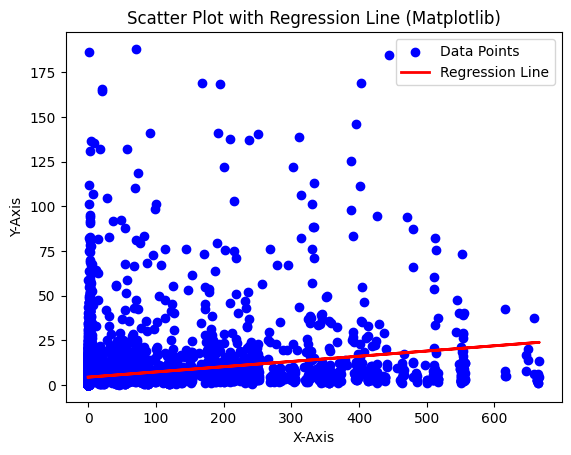

In [96]:
distances = np.zeros(len(new_pairs))
labeldiffs = np.zeros_like(distances)
for i in range(len(new_pairs) - 1):
    img_name = new_pairs[i]["day_img"]
    for j in range(len(day_dict)):
        try:
            position_a = day_dict[j][img_name]['t_w2c_orig']
            label_a = new_pairs[i]["label"]
            break
        except:
            continue
    img_name = new_pairs[i+1]["day_img"]
    for j in range(len(day_dict)):
        try:
            position_b = day_dict[j][img_name]['t_w2c_orig']
            label_b = new_pairs[i+1]["label"]
            break
        except:
            continue
    dist = np.linalg.norm(position_a - position_b)
    label_diff = np.abs(label_a - label_b)
    distances[i] = dist
    labeldiffs[i] = label_diff

x = labeldiffs
y = distances

# 1. Plot the dots (scatter plot)
plt.scatter(x, y, color="blue", label="Data Points")

# 2. Calculate the linear regression line (degree 1 polynomial)
m, b = np.polyfit(x, y, 1)

# 3. Plot the regression line using the equation: y = mx + b
plt.plot(x, m * x + b, color="red", linewidth=2, label="Regression Line")

# Add elements and show
plt.title("Scatter Plot with Regression Line (Matplotlib)")
plt.xlabel("X-Axis")
plt.ylabel("Y-Axis")
plt.legend()
plt.show()


In [91]:
print(day_dict[0])

{'35350735662.jpg': {'c_world': array([ 19.01434328, -10.17696687,  -0.02745672]), 'R_c2w': array([[-8.51043045e-04,  7.61921203e-01, -6.47669172e-01],
       [-7.33192942e-02, -6.45973757e-01, -7.59830367e-01],
       [-9.97308155e-01,  4.68399982e-02,  5.64132763e-02]]), 'R_w2c_orig': array([[-8.51043045e-04, -7.33192942e-02, -9.97308155e-01],
       [ 7.61921203e-01, -6.45973757e-01,  4.68399982e-02],
       [-6.47669172e-01, -7.59830367e-01,  5.64132763e-02]]), 't_w2c_orig': array([ -0.75736881, -21.06019876,   4.58378441])}, '36350736787.jpg': {'c_world': array([ 18.75737177, -10.38339002,  -0.07562938]), 'R_c2w': array([[-0.0234297 ,  0.6645923 , -0.74683875],
       [-0.03150664, -0.74716361, -0.66389297],
       [-0.99922889,  0.00797557,  0.03844489]]), 'R_w2c_orig': array([[-0.0234297 , -0.03150664, -0.99922889],
       [ 0.6645923 , -0.74716361,  0.00797557],
       [-0.74683875, -0.66389297,  0.03844489]]), 't_w2c_orig': array([  0.03676273, -20.22349291,   7.11818002])}, '

In [87]:
new_pairs[0]["day_img"]

'1482290562975.jpg'

In [ ]:
# Find 3 classes with exactly 4 image pairs
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

# Count pairs per label
cluster_sizes = {}
for pair in new_pairs:
    if pair['label'] in cluster_sizes.keys():
        cluster_sizes[pair['label']] += 1
    else: 
        cluster_sizes[pair['label']] = 1

# Find indices where size == 4
labels_with_4_pairs = [label for label, size in cluster_sizes.items() if size == 4]
print(f"Found {len(labels_with_4_pairs)} classes with exactly 4 pairs")
print(f"Classes with 4 pairs: {labels_with_4_pairs[10:13]}")

# Get the first 3 classes with 4 pairs
classes_to_show = labels_with_4_pairs[10:13]

# For each class, get the day image names and show the pictures
for class_label in classes_to_show:
    print(f"\n=== Class {class_label} with 4 image pairs ===")
    
    # Get all pairs for this class
    class_pairs = [pair for pair in new_pairs if pair['label'] == class_label]
    
    # Create a grid showing all 4 day images for this class
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    fig.suptitle(f'Class {class_label} - 4 Day Images', fontsize=16)
    axes = axes.flatten()
    
    for idx, pair in enumerate(class_pairs):
        day_img_name = pair['day_img']
        print(f"  Pair {idx+1}: Day Image: {day_img_name}, Night Image: {pair['night_img']}")
        
        # Find the full path to the day image
        day_img_path = None
        for file in day_images_roots[0].glob('*.jpg'):  # Using first training scene
            if file.name.endswith(day_img_name):
                day_img_path = file
                break
        
        if day_img_path and day_img_path.exists():
            day_img = Image.open(day_img_path)
            axes[idx].imshow(day_img)
            axes[idx].set_title(f"Day Image {idx+1}: {day_img_name}")
            axes[idx].axis('off')
    
    plt.tight_layout()
    plt.show()

print("\nDone showing 3 classes with 4 image pairs each!")

In [ ]:
classes = [1, 1, 2, 12, 32, 72]

# Find the full path to the day image

fig, axes = plt.subplots(2, 3, figsize=(12, 10))
#fig.suptitle(f'Class {class_label} - 4 Day Images', fontsize=16)
axes = axes.flatten()
counter = 0
for c in classes:
    day_img_name = cluster_center_labeled_dict_flat[c]

    day_img_path = None
    for file in day_images_roots[0].glob('*.jpg'):  # Using first training scene
        if file.name.endswith(day_img_name):
            day_img_path = file
            break
    
    if day_img_path is None:
        print("day_img_path is None")
    if not day_img_path.exists():
        print("day_img_path doesnt exist")

    if day_img_path and day_img_path.exists():
        day_img = Image.open(day_img_path)
        plt.show(day_img)
    counter+=1